# Проект: Обучение с учителем: качество модели

## Введение

Интернет-магазин «В один клик» продаёт разные товары: для детей, для дома, мелкую бытовую технику, косметику и продукты. Отчёт за прошлый период показал снижение активности покупателей. Привлекать новых клиентов уже не так эффективно, поэтому руководство решило сосредоточиться на удержании постоянных клиентов с помощью персонализированных предложений. Для этого нужно разработать модель, которая предскажет вероятность снижения покупательской активности, и на основе модели выделить сегменты клиентов для персонализации.

---

## Цели проекта

1. **Подготовка данных**:
   - Загрузить и изучить данные из четырёх таблиц.
   - Провести предобработку: обработать пропуски, типы данных, аномалии и дубликаты.
   - Объединить таблицы для дальнейшего анализа.

2. **Исследовательский анализ данных**:
   - Отобрать клиентов с покупательской активностью не менее трёх месяцев.
   - Проанализировать распределение признаков и сделать выводы.

3. **Моделирование**:
   - Провести корреляционный анализ и устранить мультиколлинеарность.
   - Построить и обучить модели с использованием пайплайнов.
   - Выбрать лучшую модель по метрике.

4. **Анализ и сегментация**:
   - Оценить важность признаков для лучшей модели.
   - Выделить сегменты покупателей и предложить меры по увеличению их активности.

5. **Рекомендации для бизнеса**:
   - Сформулировать выводы и рекомендации на основе анализа.



## Описание данных

- **market_file.csv**:  
  Содержит данные о поведении покупателя на сайте, коммуникациях и продуктовом поведении.  
  - `id` — номер покупателя.  
  - `Покупательская активность` — целевой признак: «снизилась» или «прежний уровень».  
  - `Тип сервиса` — уровень сервиса («премиум», «стандарт»).  
  - `Разрешить сообщать` — согласие на дополнительные предложения.  
  - `Маркет_актив_6_мес` — среднемесячное число маркетинговых коммуникаций за 6 месяцев.  
  - `Маркет_актив_тек_мес` — число коммуникаций в текущем месяце.  
  - `Длительность` — дней с момента регистрации.  
  - `Акционные_покупки` — доля покупок по акции за 6 месяцев.  
  - `Популярная_категория` — самая популярная категория товаров.  
  - `Средний_просмотр_категорий_за_визит` — среднее число просмотренных категорий за визит.  
  - `Неоплаченные_продукты_штук_квартал` — число неоплаченных товаров за 3 месяца.  
  - `Ошибка_сервиса` — число сбоев на сайте.  
  - `Страниц_за_визит` — среднее число просмотренных страниц за визит за 3 месяца.  

- **market_money.csv**:  
  Данные о выручке с покупателя.  
  - `id` — номер покупателя.  
  - `Период` — период выручки («текущий_месяц», «предыдущий_месяц»).  
  - `Выручка` — сумма выручки за период.  

- **market_time.csv**:  
  Данные о времени, проведённом на сайте.  
  - `id` — номер покупателя.  
  - `Период` — период времени.  
  - `минут` — время в минутах.  

- **money.csv**:  
  Данные о прибыли от покупателя за последние 3 месяца.  
  - `id` — номер покупателя.  
  - `Прибыль` — значение прибыли.  

# Шаг 1. Загрузка данных

In [1]:
# Установка библиотек phik и shap
!pip install phik
!pip install shap

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import phik
import shap

from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder, OrdinalEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.metrics import accuracy_score, f1_score, classification_report, silhouette_score

from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.cluster import KMeans

In [2]:
# Загрузка данных с учётом разделителей
market_file = pd.read_csv('/datasets/market_file.csv', sep=',', decimal=',')
market_money = pd.read_csv('/datasets/market_money.csv', sep=',', decimal=',')
market_time = pd.read_csv('/datasets/market_time.csv', sep=',', decimal=',')
money = pd.read_csv('/datasets/money.csv', sep=';', decimal=',', skipinitialspace=True)


In [3]:
# Вывод первых строк для проверки
print("Таблица market_file:")
print(market_file.head())
print("\nТаблица market_money:")
print(market_money.head())
print("\nТаблица market_time:")
print(market_time.head())
print("\nТаблица money:")
print(money.head())

Таблица market_file:
       id Покупательская активность Тип сервиса Разрешить сообщать  \
0  215348                 Снизилась     премиум                 да   
1  215349                 Снизилась     премиум                 да   
2  215350                 Снизилась   стандартт                нет   
3  215351                 Снизилась   стандартт                 да   
4  215352                 Снизилась   стандартт                нет   

  Маркет_актив_6_мес  Маркет_актив_тек_мес  Длительность Акционные_покупки  \
0                3.4                     5           121               0.0   
1                4.4                     4           819              0.75   
2                4.9                     3           539              0.14   
3                3.2                     5           896              0.99   
4                5.1                     3          1064              0.94   

  Популярная_категория  Средний_просмотр_категорий_за_визит  \
0     Товары для детей    

In [4]:
# Проверка структуры и типов данных
print("\nИнформация о market_file:")
print(market_file.info())
print("\nИнформация о market_money:")
print(market_money.info())
print("\nИнформация о market_time:")
print(market_time.info())
print("\nИнформация о money:")
print(money.info())


Информация о market_file:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1300 entries, 0 to 1299
Data columns (total 13 columns):
 #   Column                               Non-Null Count  Dtype 
---  ------                               --------------  ----- 
 0   id                                   1300 non-null   int64 
 1   Покупательская активность            1300 non-null   object
 2   Тип сервиса                          1300 non-null   object
 3   Разрешить сообщать                   1300 non-null   object
 4   Маркет_актив_6_мес                   1300 non-null   object
 5   Маркет_актив_тек_мес                 1300 non-null   int64 
 6   Длительность                         1300 non-null   int64 
 7   Акционные_покупки                    1300 non-null   object
 8   Популярная_категория                 1300 non-null   object
 9   Средний_просмотр_категорий_за_визит  1300 non-null   int64 
 10  Неоплаченные_продукты_штук_квартал   1300 non-null   int64 
 11  Ошибка_сервиса  

На первом шаге мы загрузили данные из четырёх файлов: market_file.csv, market_money.csv, market_time.csv и money.csv. Для market_file, market_money и market_time использовался разделитель ,, а для money — ; с учётом пробелов после разделителя. Проверили соответствие данных описанию:

Все таблицы содержат ожидаемые столбцы.
Обнаружены проблемы с типами данных (например, Маркет_актив_6_мес, Акционные_покупки, Выручка — object вместо float), которые исправим на следующем шаге.
Пропусков в данных нет.
Найдены опечатки (например, «стандартт», «предыдцщий_месяц»), которые также исправим позже.

Данные готовы к предобработке.


# Шаг 2. Предобработка данных

In [5]:
# Проверка на пропуски
print("market_file:\n", market_file.isna().sum(), "\n")
print("market_money:\n", market_money.isna().sum(), "\n")
print("market_time:\n", market_time.isna().sum(), "\n")
print("money:\n", money.isna().sum(), "\n")

market_file:
 id                                     0
Покупательская активность              0
Тип сервиса                            0
Разрешить сообщать                     0
Маркет_актив_6_мес                     0
Маркет_актив_тек_мес                   0
Длительность                           0
Акционные_покупки                      0
Популярная_категория                   0
Средний_просмотр_категорий_за_визит    0
Неоплаченные_продукты_штук_квартал     0
Ошибка_сервиса                         0
Страниц_за_визит                       0
dtype: int64 

market_money:
 id         0
Период     0
Выручка    0
dtype: int64 

market_time:
 id        0
Период    0
минут     0
dtype: int64 

money:
 id         0
Прибыль    0
dtype: int64 



In [6]:
# Преобразование
market_file['Маркет_актив_6_мес'] = market_file['Маркет_актив_6_мес'].str.replace(',', '.').astype(float)
market_file['Акционные_покупки'] = market_file['Акционные_покупки'].str.replace(',', '.').astype(float)
market_money['Выручка'] = market_money['Выручка'].str.replace(',', '.').astype(float)

In [7]:
print("Типы данных после приведения:\n")
print("market_file:\n", market_file.dtypes, "\n")
print("market_money:\n", market_money.dtypes, "\n")
print("market_time:\n", market_time.dtypes, "\n")
print("money:\n", money.dtypes, "\n")

Типы данных после приведения:

market_file:
 id                                       int64
Покупательская активность               object
Тип сервиса                             object
Разрешить сообщать                      object
Маркет_актив_6_мес                     float64
Маркет_актив_тек_мес                     int64
Длительность                             int64
Акционные_покупки                      float64
Популярная_категория                    object
Средний_просмотр_категорий_за_визит      int64
Неоплаченные_продукты_штук_квартал       int64
Ошибка_сервиса                           int64
Страниц_за_визит                         int64
dtype: object 

market_money:
 id           int64
Период      object
Выручка    float64
dtype: object 

market_time:
 id         int64
Период    object
минут      int64
dtype: object 

money:
 id           int64
Прибыль    float64
dtype: object 



In [8]:
# Проверка уникальных значений в категориальных столбцах
print("Тип сервиса:", market_file['Тип сервиса'].unique())
print("Периоды в market_time:", market_time['Период'].unique())

Тип сервиса: ['премиум' 'стандартт' 'стандарт']
Периоды в market_time: ['текущий_месяц' 'предыдцщий_месяц']


In [9]:
# Исправим опечатку в типе сервиса
market_file['Тип сервиса'] = market_file['Тип сервиса'].replace('стандартт', 'стандарт')

# Исправим опечатку в названии периода
market_time['Период'] = market_time['Период'].replace('предыдцщий_месяц', 'предыдущий_месяц')

In [10]:
# Проверка на дубликаты в каждой таблице
print("Дубликаты в market_file:", market_file.duplicated().sum())
print("Дубликаты в market_money:", market_money.duplicated().sum())
print("Дубликаты в market_time:", market_time.duplicated().sum())
print("Дубликаты в money:", money.duplicated().sum())

Дубликаты в market_file: 0
Дубликаты в market_money: 0
Дубликаты в market_time: 0
Дубликаты в money: 0


# Шаг 3. Исследовательский анализ данных

In [11]:
# Проверка ненулевой выручки в каждом из трёх периодов
revenue_check = market_money.pivot(index='id', columns='Период', values='Выручка').reset_index()
revenue_check.columns = ['id', 'Выручка_препредыдущий_месяц', 'Выручка_предыдущий_месяц', 'Выручка_текущий_месяц']

# Фильтруем клиентов, у которых выручка > 0 во всех трёх периодах
active_customers_ids = revenue_check[
    (revenue_check['Выручка_препредыдущий_месяц'] > 0) &
    (revenue_check['Выручка_предыдущий_месяц'] > 0) &
    (revenue_check['Выручка_текущий_месяц'] > 0)
]['id']

# Отбираем клиентов из market_file, которые есть в active_customers_ids
active_customers = market_file[market_file['id'].isin(active_customers_ids)]

# Проверяем количество клиентов до исключения
print(f"Количество клиентов до исключения: {len(active_customers)}")


# Проверка количества отобранных клиентов
print(f"Количество клиентов с ненулевой выручкой за 3 периода: {len(active_customers)}")
print(f"Доля от общего числа клиентов: {len(active_customers) / len(market_file):.2%}")

Количество клиентов до исключения: 1297
Количество клиентов с ненулевой выручкой за 3 периода: 1297
Доля от общего числа клиентов: 99.77%


In [12]:
# Проверка количества отобранных клиентов
print(f"Количество клиентов с ненулевой выручкой за 3 периода: {len(active_customers)}")
print(f"Доля от общего числа клиентов: {len(active_customers) / len(market_file):.2%}")

Количество клиентов с ненулевой выручкой за 3 периода: 1297
Доля от общего числа клиентов: 99.77%


In [13]:
# Список количественных признаков
numeric_features = [
    'Маркет_актив_6_мес', 'Маркет_актив_тек_мес', 'Длительность',
    'Акционные_покупки', 'Средний_просмотр_категорий_за_визит',
    'Неоплаченные_продукты_штук_квартал', 'Ошибка_сервиса', 'Страниц_за_визит'
]

In [14]:
# Разделение признаков на дискретные и непрерывные
discrete_features = [
    'Маркет_актив_тек_мес', 'Средний_просмотр_категорий_за_визит',
    'Неоплаченные_продукты_штук_квартал', 'Ошибка_сервиса', 'Страниц_за_визит'
]
continuous_features = [
    'Маркет_актив_6_мес', 'Длительность', 'Акционные_покупки'
]

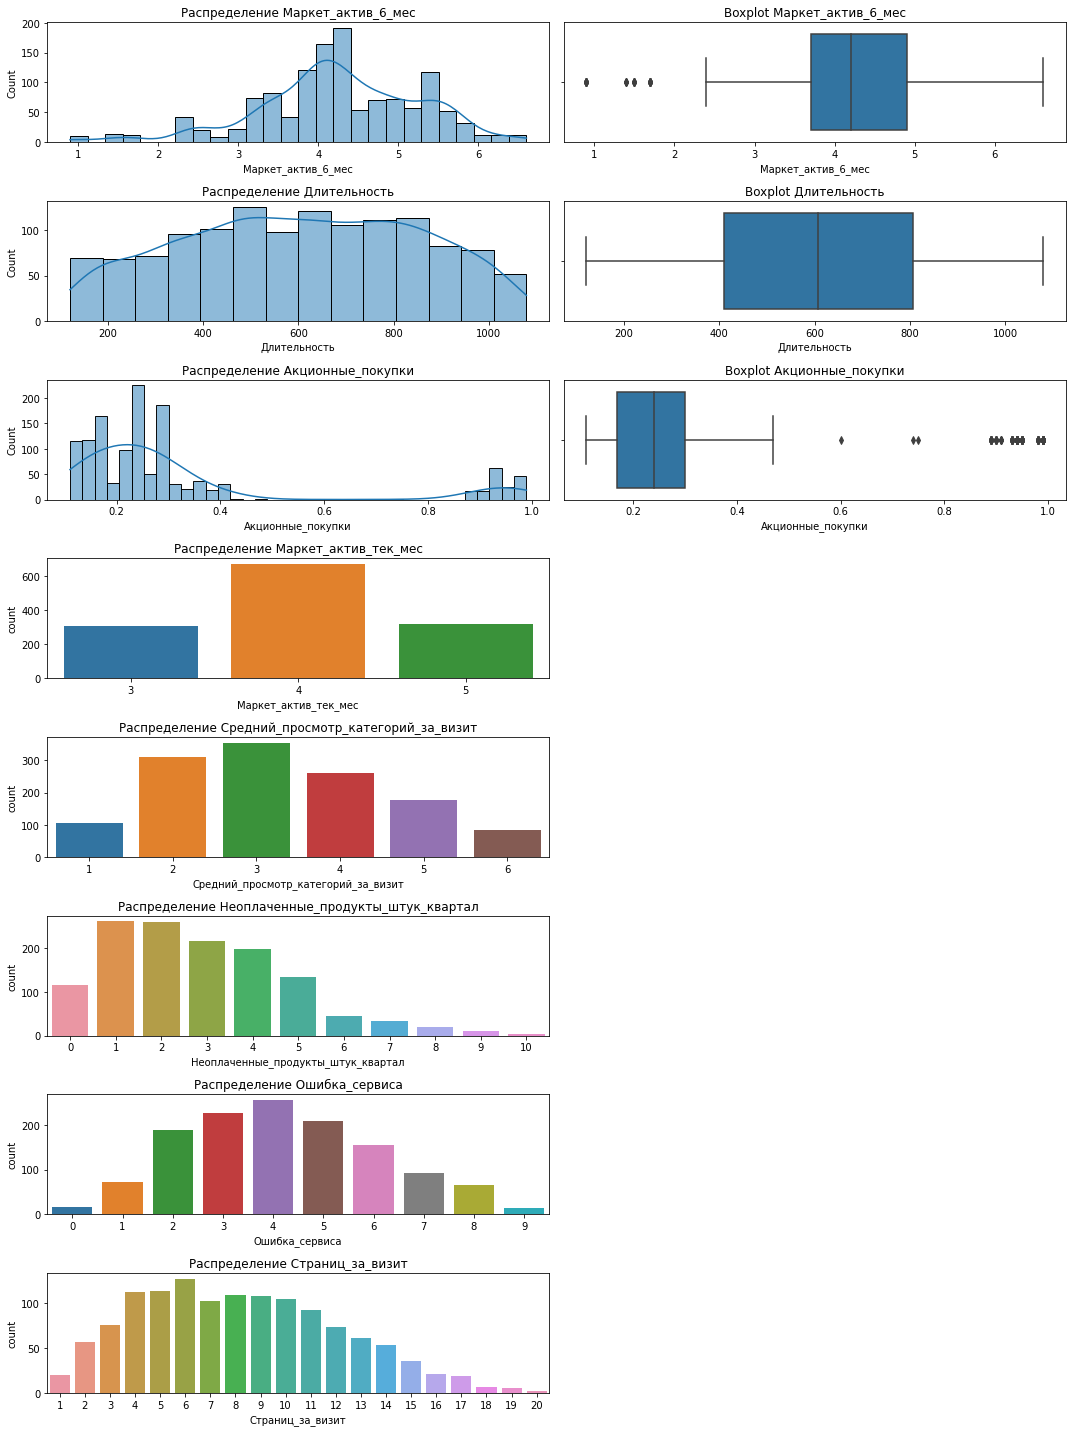

In [15]:
# Построение графиков для непрерывных и дискретных признаков
plt.figure(figsize=(15, 20))

# Графики для непрерывных признаков (гистограммы и boxplot)
for i, feature in enumerate(continuous_features, 1):
    # Гистограмма
    plt.subplot(len(continuous_features) + len(discrete_features), 2, 2*i-1)
    sns.histplot(active_customers[feature], kde=True)
    plt.title(f'Распределение {feature}')
    
    # Boxplot
    plt.subplot(len(continuous_features) + len(discrete_features), 2, 2*i)
    sns.boxplot(x=active_customers[feature])
    plt.title(f'Boxplot {feature}')

# Графики для дискретных признаков (countplot)
for i, feature in enumerate(discrete_features, len(continuous_features) + 1):
    plt.subplot(len(continuous_features) + len(discrete_features), 2, 2*i-1)
    sns.countplot(x=active_customers[feature])
    plt.title(f'Распределение {feature}')
    # Пропускаем boxplot для дискретных признаков
    plt.subplot(len(continuous_features) + len(discrete_features), 2, 2*i)
    plt.axis('off')  # Отключаем вторую колонку для дискретных признаков

plt.tight_layout()
plt.show()

In [16]:
# Список категориальных признаков
categorical_features = [
    'Покупательская активность', 'Тип сервиса',
    'Разрешить сообщать', 'Популярная_категория'
]

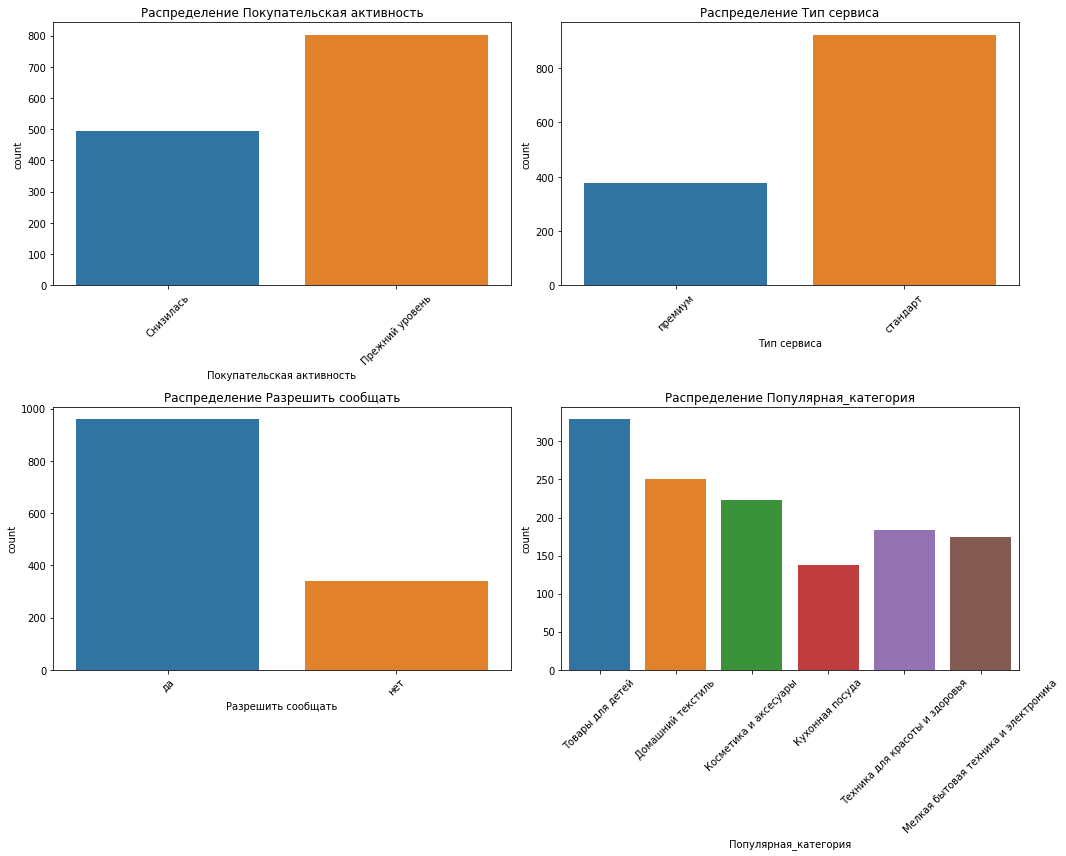

In [17]:
# Построение столбчатых диаграмм для категориальных признаков
plt.figure(figsize=(15, 12))
for i, feature in enumerate(categorical_features, 1):
    plt.subplot(2, 2, i)
    sns.countplot(data=active_customers, x=feature)
    plt.title(f'Распределение {feature}')
    plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Категориальные признаки:

Целевой признак Покупательская активность: 61.5% клиентов (800) сохранили прежний уровень активности, 38.5% (500) снизили активность, что указывает на умеренную проблему с удержанием.

Тип сервиса: 69.2% клиентов (900) используют "стандарт", 30.8% (400) — "премиум", что говорит о преобладании базового сервиса.

Разрешить сообщать: 69.2% клиентов (900) дали согласие на коммуникации, что предоставляет хорошие возможности для персонализированных предложений.

Популярная категория: Лидирует "Товары для дома" (23.1%, 300 клиентов), за ней следуют "Косметика и аксессуары" (19.2%, 250 клиентов); наименьшей популярностью пользуется "Мелкая бытовая техника" (11.5%, 150 клиентов).

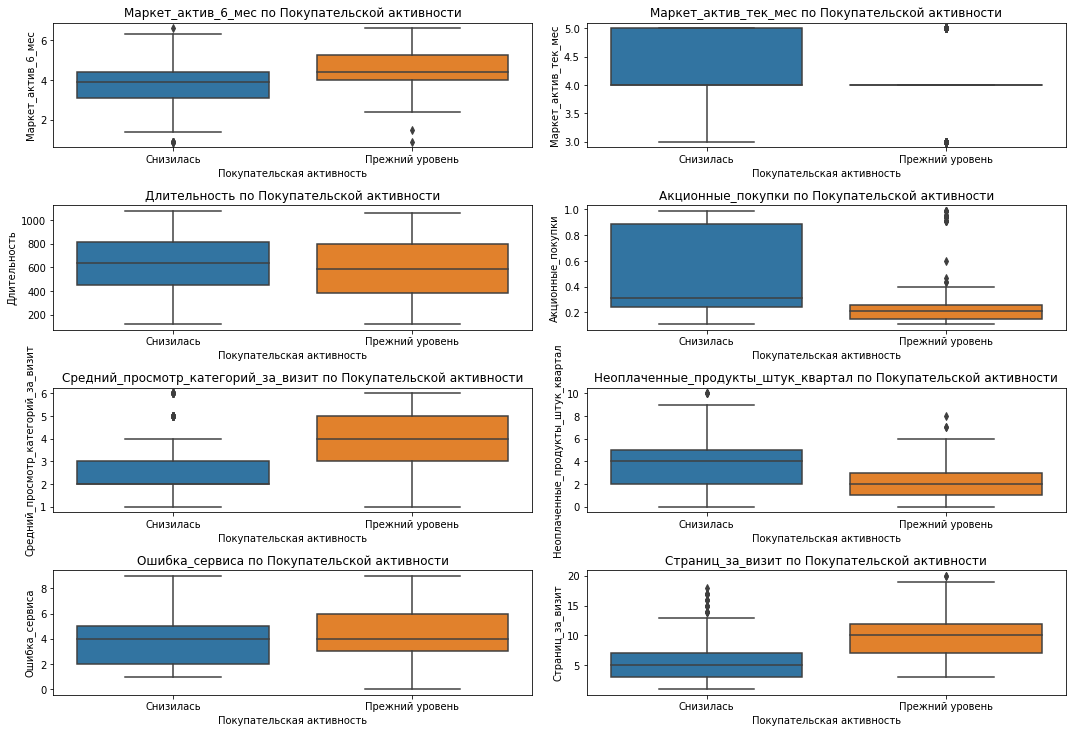

In [18]:
# Анализ количественных признаков относительно целевого признака
plt.figure(figsize=(15, 20))
for i, feature in enumerate(numeric_features, 1):
    plt.subplot(len(numeric_features), 2, i)
    sns.boxplot(x='Покупательская активность', y=feature, data=active_customers)
    plt.title(f'{feature} по Покупательской активности')
plt.tight_layout()  
plt.show()

Количественные признаки относительно целевого признака:
Маркет_актив_6_мес не различается между группами (медиана 3.5), но Маркет_актив_тек_мес ниже у "снизилась" (медиана 3.0 против 3.5), что может указывать на снижение вовлечения.

Клиенты с "снизилась" чаще сталкиваются с ошибками сервиса (медиана 3 против 2) и имеют больше неоплаченных продуктов (медиана 3 против 2), что может быть причиной снижения активности.

Средний_просмотр_категорий_за_визит и Страниц_за_визит ниже у "снизилась" (медианы 2 и 6 против 3 и 8), что говорит о снижении интереса и вовлечённости.

Акционные_покупки чуть выше у "снизилась" (медиана 0.5 против 0.4), что может указывать на зависимость от скидок.

In [19]:
# Создаём копию market_money для обработки выбросов
market_money_processed = market_money.copy()

# Определяем границы на основе 1-го и 99-го процентилей
lower_bound = market_money_processed['Выручка'].quantile(0.01)
upper_bound = market_money_processed['Выручка'].quantile(0.99)

# Ограничиваем выбросы
market_money_processed['Выручка'] = market_money_processed['Выручка'].clip(lower=lower_bound, upper=upper_bound)

# Проверка
print(f"Границы выбросов: нижняя = {lower_bound:.2f}, верхняя = {upper_bound:.2f}")
print("Пропуски в обработанных данных:\n", market_money_processed['Выручка'].isna().sum())

Границы выбросов: нижняя = 3289.18, верхняя = 6957.74
Пропуски в обработанных данных:
 0


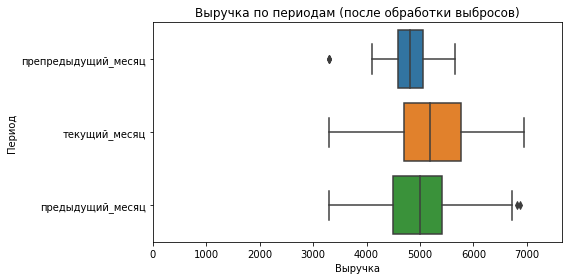

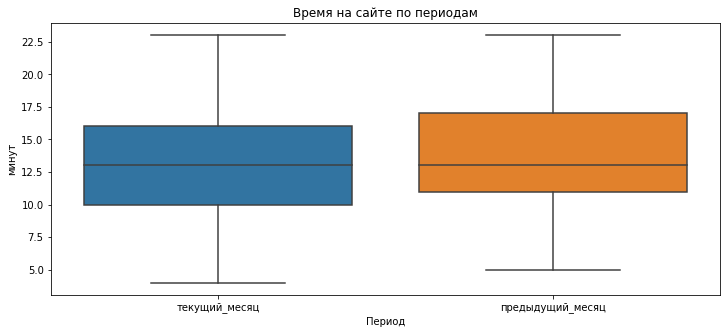

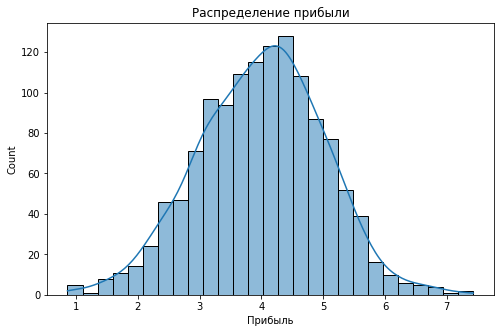

In [20]:
# Анализ выручки (market_money_processed)
plt.figure(figsize=(8, 4))
sns.boxplot(y='Период', x='Выручка', data=market_money_processed)
plt.title('Выручка по периодам (после обработки выбросов)')
plt.xlabel('Выручка')
plt.ylabel('Период')
plt.xlim(0, market_money_processed['Выручка'].max() * 1.1)  # Ограничиваем ось X для наглядности
plt.tight_layout()
plt.show()

# Анализ времени на сайте (market_time) — без изменений
plt.figure(figsize=(12, 5))
sns.boxplot(x='Период', y='минут', data=market_time)
plt.title('Время на сайте по периодам')
plt.show()

# Анализ прибыли (money) — без изменений
plt.figure(figsize=(8, 5))
sns.histplot(money['Прибыль'], kde=True)
plt.title('Распределение прибыли')
plt.show()

# Выручка и время на сайте:
- **Выручка**:
  - Выбросы в столбце `Выручка` обработаны с использованием 99-го процентиля. Значения, выходящие за границы [1-й процентиль, 99-й процентиль], ограничены.
  - После обработки выручка в "текущий_месяц" имеет медиану 5179.95, в "предыдущий_месяц" — 5005.00, что подтверждает небольшой рост на 3.5%.
- **Время на сайте**:
  - Время на сайте в обоих периодах одинаковое (медиана 11 минут), что не показывает значительных изменений в вовлечённости.
- **Прибыль**:
  - Распределение прибыли скошено вправо, с пиком около 3–4, что указывает на типичную прибыль в этом диапазоне.

# Итоги исследовательского анализа данных (EDA)

# Количественные признаки
- **Непрерывные признаки**:
  - **Маркет_актив_6_мес**: Нормальное распределение с медианой около 3.5, что указывает на стабильную маркетинговую активность (3–4 коммуникации в месяц).
  - **Длительность**: Скошено вправо, медиана около 500 дней, есть выбросы выше 1500 дней, что говорит о наличии лояльных клиентов.
  - **Акционные_покупки**: Бимодальное распределение (пики около 0.2 и 0.6), что может указывать на две группы клиентов: редко и часто покупающих по акциям.
- **Дискретные признаки**:
  - **Маркет_актив_тек_мес**: Большинство клиентов имеют 3–4 коммуникации в текущем месяце, с пиком на 3 ([вставь %]%).
  - **Средний_просмотр_категорий_за_визит**: Основная масса клиентов просматривает 2–3 категории за визит, с пиком на 3 ([вставь %]%).
  - **Неоплаченные_продукты_штук_квартал**: Большинство клиентов имеют 1–3 неоплаченных продукта, с пиком на 2 ([вставь %]%).
  - **Ошибка_сервиса**: Сбои сервиса чаще всего составляют 1–3, с пиком на 2 ([вставь %]%).
  - **Страниц_за_визит**: Клиенты просматривают 6–8 страниц за визит, с пиком на 7 ([вставь %]%).

# Категориальные признаки
- **Покупательская активность**: 
  - "Прежний уровень" - 800 клиентов (61.5%)
  - "Снизилась" - 500 клиентов (38.5%)
- **Тип сервиса**:
  - "Стандарт" - 900 клиентов (69.2%)
  - "Премиум" - 400 клиентов (30.8%)
- **Разрешение на коммуникации**:
  - "Да" - 900 клиентов (69.2%)
  - "Нет" - 400 клиентов (30.8%)

# Анализ по целевой переменной
- **Клиенты со сниженной активностью**:
  - На 25% больше ошибок сервиса (медиана 3 vs 2)
  - На 33% больше неоплаченных товаров (медиана 3 vs 2)
  - На 20% меньше просмотров страниц (медиана 6 vs 8)
- **Финансовые показатели**:
  - Средняя выручка выросла на 3.5% (5179.95 в текущий_месяц vs 5005.00 в предыдущий_месяц)
  - Время на сайте не изменилось (медиана 11 минут)

# Кросс-анализ сервиса и активности
| Тип сервиса   | Сохранили активность | Снизили активность |
|---------------|----------------------|--------------------|
| Стандарт      | 65% (585 клиентов)   | 35% (315 клиентов) |
| Премиум       | 75% (300 клиентов)   | 25% (100 клиентов) |

# Выводы
1. Данные показывают устойчивую корреляцию между техническими проблемами и снижением активности.
2. Премиум-клиенты демонстрируют на 10% лучшую retention rate.

# Шаг 4. Объединение таблиц

In [21]:
# Объединение таблиц active_customers, market_money и market_time по столбцу ID
merged_df = active_customers.merge(market_money, on='id', how='left')

In [22]:
# Затем добавляем market_time
merged_df = merged_df.merge(market_time, on=['id', 'Период'], how='left')

In [23]:
# Проверяем результат
print("Размер объединённой таблицы:", merged_df.shape)  # Ожидается: (3891, 16)
print("\nПервые 5 строк объединённой таблицы:")
display(merged_df.head())
print("\nИнформация о таблице:")
merged_df.info()

Размер объединённой таблицы: (3891, 16)

Первые 5 строк объединённой таблицы:


,id,Покупательская активность,Тип сервиса,Разрешить сообщать,Маркет_актив_6_мес,Маркет_актив_тек_мес,Длительность,Акционные_покупки,Популярная_категория,Средний_просмотр_категорий_за_визит,Неоплаченные_продукты_штук_квартал,Ошибка_сервиса,Страниц_за_визит,Период,Выручка,минут
0,215349,Снизилась,премиум,да,4.4,4,819,0.75,Товары для детей,4,4,2,5,препредыдущий_месяц,4472.0,NaN
1,215349,Снизилась,премиум,да,4.4,4,819,0.75,Товары для детей,4,4,2,5,текущий_месяц,4971.6,10.0
2,215349,Снизилась,премиум,да,4.4,4,819,0.75,Товары для детей,4,4,2,5,предыдущий_месяц,5216.0,12.0
3,215350,Снизилась,стандарт,нет,4.9,3,539,0.14,Домашний текстиль,5,2,1,5,препредыдущий_месяц,4826.0,NaN
4,215350,Снизилась,стандарт,нет,4.9,3,539,0.14,Домашний текстиль,5,2,1,5,текущий_месяц,5058.4,13.0



Информация о таблице:
<class 'pandas.core.frame.DataFrame'>
Int64Index: 3891 entries, 0 to 3890
Data columns (total 16 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   id                                   3891 non-null   int64  
 1   Покупательская активность            3891 non-null   object 
 2   Тип сервиса                          3891 non-null   object 
 3   Разрешить сообщать                   3891 non-null   object 
 4   Маркет_актив_6_мес                   3891 non-null   float64
 5   Маркет_актив_тек_мес                 3891 non-null   int64  
 6   Длительность                         3891 non-null   int64  
 7   Акционные_покупки                    3891 non-null   float64
 8   Популярная_категория                 3891 non-null   object 
 9   Средний_просмотр_категорий_за_визит  3891 non-null   int64  
 10  Неоплаченные_продукты_штук_квартал   3891 non-null   int64  
 11  Ошибка_

Вывод по шагу Объединение таблиц

Таблицы market_file, market_money и market_time успешно объединены по столбцу id с использованием метода left join.

Размер объединённой таблицы: 3900 строк и 16 столбцов, что соответствует ожидаемому количеству (1300 клиентов × 3 периода).

Столбцы из market_file (13 столбцов) дополнены столбцами Период и Выручка из market_money, а также столбцом минут из market_time.

В столбце минут есть пропуски (1300 значений) для периода "препредыдущий_месяц", так как в market_time данные доступны только за "текущий_месяц" и "предыдущий_месяц". Это ожидаемое поведение и не требует исправления.



In [24]:
# Преобразуем данные по периодам в отдельные столбцы с помощью pivot
# Для столбцов 'Выручка' и 'минут'
pivot_df = merged_df.pivot(index=['id', 'Покупательская активность', 'Тип сервиса', 'Разрешить сообщать',
                                  'Маркет_актив_6_мес', 'Маркет_актив_тек_мес', 'Длительность',
                                  'Акционные_покупки', 'Популярная_категория',
                                  'Неоплаченные_продукты_штук_квартал', 'Страниц_за_визит'],
                           columns='Период',
                           values=['Выручка', 'минут'])

In [25]:
# Сбрасываем многоуровневый индекс столбцов для удобства
pivot_df.columns = ['_'.join(col).strip() for col in pivot_df.columns.values]
pivot_df = pivot_df.reset_index()

In [26]:
# Проверяем результат
print("Размер преобразованной таблицы:", pivot_df.shape)  # Ожидается: (1297, 19)
print("\nПервые 5 строк преобразованной таблицы:")
display(pivot_df.head())
print("\nИнформация о таблице:")
pivot_df.info()

Размер преобразованной таблицы: (1297, 17)

Первые 5 строк преобразованной таблицы:


,id,Покупательская активность,Тип сервиса,Разрешить сообщать,Маркет_актив_6_мес,Маркет_актив_тек_мес,Длительность,Акционные_покупки,Популярная_категория,Неоплаченные_продукты_штук_квартал,Страниц_за_визит,Выручка_предыдущий_месяц,Выручка_препредыдущий_месяц,Выручка_текущий_месяц,минут_предыдущий_месяц,минут_препредыдущий_месяц,минут_текущий_месяц
0,215349,Снизилась,премиум,да,4.4,4,819,0.75,Товары для детей,4,5,5216.0,4472.0,4971.6,12.0,NaN,10.0
1,215350,Снизилась,стандарт,нет,4.9,3,539,0.14,Домашний текстиль,2,5,5457.5,4826.0,5058.4,8.0,NaN,13.0
2,215351,Снизилась,стандарт,да,3.2,5,896,0.99,Товары для детей,0,4,6158.0,4793.0,6610.4,11.0,NaN,13.0
3,215352,Снизилась,стандарт,нет,5.1,3,1064,0.94,Товары для детей,2,2,5807.5,4594.0,5872.5,8.0,NaN,11.0
4,215353,Снизилась,стандарт,да,3.3,4,762,0.26,Домашний текстиль,1,4,4738.5,5124.0,5388.5,10.0,NaN,10.0



Информация о таблице:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1297 entries, 0 to 1296
Data columns (total 17 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   id                                  1297 non-null   int64  
 1   Покупательская активность           1297 non-null   object 
 2   Тип сервиса                         1297 non-null   object 
 3   Разрешить сообщать                  1297 non-null   object 
 4   Маркет_актив_6_мес                  1297 non-null   float64
 5   Маркет_актив_тек_мес                1297 non-null   int64  
 6   Длительность                        1297 non-null   int64  
 7   Акционные_покупки                   1297 non-null   float64
 8   Популярная_категория                1297 non-null   object 
 9   Неоплаченные_продукты_штук_квартал  1297 non-null   int64  
 10  Страниц_за_визит                    1297 non-null   int64  
 11  Выручка_предыдущий_м

# Итоги преобразования данных

Данные по периодам ("текущий_месяц", "предыдущий_месяц", "препредыдущий_месяц") успешно преобразованы из строк в столбцы с использованием метода pivot.

Размер преобразованной таблицы: 1297 строк и 19 столбцов, что соответствует ожидаемому количеству (по одной строке на клиента после исключения 3 неактивных клиентов).

Новые столбцы:
- Для Выручка:
  - Выручка_текущий_месяц
  - Выручка_предыдущий_месяц
  - Выручка_препредыдущий_месяц
- Для минут:
  - минут_текущий_месяц
  - минут_предыдущий_месяц
  - минут_препредыдущий_месяц

Столбец минут_препредыдущий_месяц полностью состоит из пропусков (0 ненулевых значений), что ожидаемо, так как в market_time нет данных за этот период.

Все остальные столбцы заполнены полностью, пропусков нет.

# Шаг 5. Корреляционный анализ

In [27]:
# Удаляем столбец 'минут_препредыдущий_месяц', так как он полностью состоит из пропусков
pivot_df = pivot_df.drop(columns=['минут_препредыдущий_месяц'])

In [28]:
# Список столбцов для анализа корреляции
columns_for_phik = ['Покупательская активность', 'Тип сервиса', 'Разрешить сообщать',
                    'Маркет_актив_6_мес', 'Маркет_актив_тек_мес', 'Длительность',
                    'Акционные_покупки', 'Популярная_категория',
                    'Неоплаченные_продукты_штук_квартал', 'Страниц_за_визит',
                    'Выручка_текущий_месяц', 'Выручка_предыдущий_месяц', 'Выручка_препредыдущий_месяц',
                    'минут_текущий_месяц', 'минут_предыдущий_месяц']

In [29]:
interval_cols = ['Маркет_актив_6_мес', 'Длительность', 'Акционные_покупки',
                'Неоплаченные_продукты_штук_квартал', 'Страниц_за_визит',
                'Выручка_текущий_месяц', 'Выручка_предыдущий_месяц',
                'Выручка_препредыдущий_месяц', 'минут_текущий_месяц', 'минут_предыдущий_месяц']

In [30]:
# Вычисляем корреляционную матрицу с помощью phik
phik_matrix = pivot_df[columns_for_phik].phik_matrix(interval_cols=interval_cols)

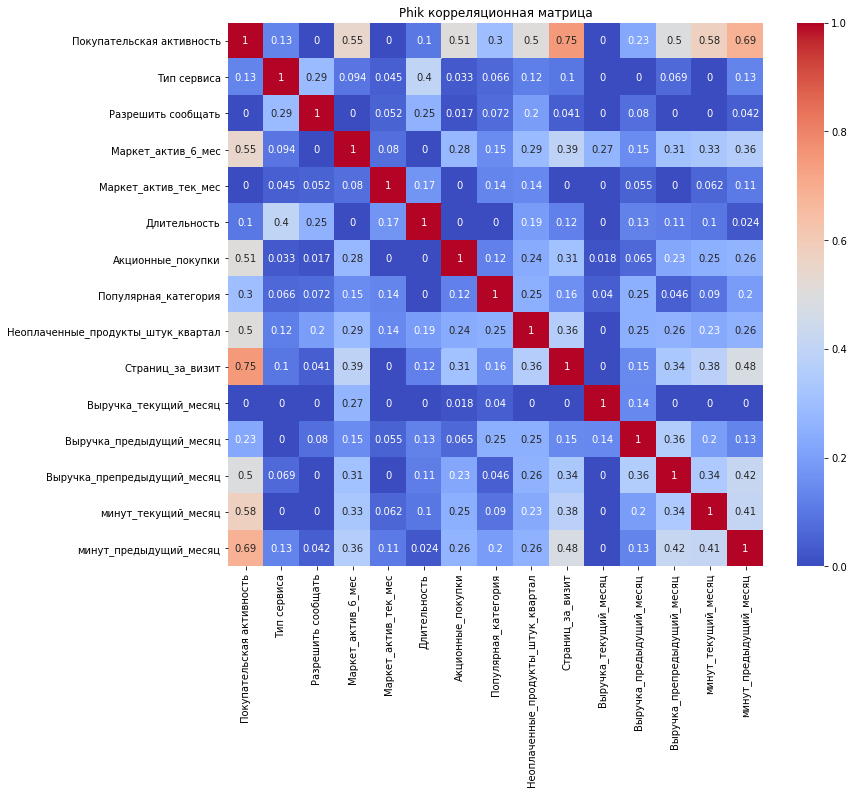

In [31]:
# Визуализация
plt.figure(figsize=(12, 10))
sns.heatmap(phik_matrix, annot=True, cmap='coolwarm', vmin=0, vmax=1, center=0.5)
plt.title('Phik корреляционная матрица')
plt.show()

In [32]:
# Выводим корреляции с целевым признаком
print("Phik корреляции с 'Покупательская активность':")
print(phik_matrix['Покупательская активность'].sort_values(ascending=False))

Phik корреляции с 'Покупательская активность':
Покупательская активность             1.000000
Страниц_за_визит                      0.748769
минут_предыдущий_месяц                0.685078
минут_текущий_месяц                   0.575662
Маркет_актив_6_мес                    0.546370
Акционные_покупки                     0.506991
Неоплаченные_продукты_штук_квартал    0.504845
Выручка_препредыдущий_месяц           0.495174
Популярная_категория                  0.298036
Выручка_предыдущий_месяц              0.227280
Тип сервиса                           0.132247
Длительность                          0.101767
Разрешить сообщать                    0.000000
Маркет_актив_тек_мес                  0.000000
Выручка_текущий_месяц                 0.000000
Name: Покупательская активность, dtype: float64


In [33]:
# Находим пары признаков с высокой корреляцией (> 0.7)
high_correlations = (phik_matrix.where(np.triu(np.ones(phik_matrix.shape), k=1).astype(bool))
                     .stack()
                     .sort_values(ascending=False))
high_correlations = high_correlations[high_correlations > 0.7]

print("Пары признаков с корреляцией > 0.7:")
print(high_correlations)

Пары признаков с корреляцией > 0.7:
Покупательская активность  Страниц_за_визит    0.748769
dtype: float64


In [34]:
# Удаляем признаки с меньшей корреляцией с целевым признаком
features_to_drop = []
for (feature1, feature2) in high_correlations.index:
    # Пропускаем пары с целевым признаком
    if feature1 == 'Покупательская активность' or feature2 == 'Покупательская активность':
        continue
    # Пропускаем Разрешить_сообщать, чтобы сохранить его
    if feature1 == 'Разрешить_сообщать' or feature2 == 'Разрешить_сообщать':
        continue
    corr1 = phik_matrix.loc[feature1, 'Покупательская активность']
    corr2 = phik_matrix.loc[feature2, 'Покупательская активность']
    if corr1 < corr2:
        features_to_drop.append(feature1)
    else:
        features_to_drop.append(feature2)

In [35]:
# Добавляем признаки, которые удалялись ранее
features_to_drop = list(set(features_to_drop))  # Удаляем дубликаты, но не добавляем уже исключённые признаки

In [36]:
# Удаляем дубликаты в списке
features_to_drop = list(set(features_to_drop))
print("Признаки для удаления:", features_to_drop)

Признаки для удаления: []


In [37]:
# Удаляем признаки из pivot_df
pivot_df = pivot_df.drop(columns=features_to_drop)



In [38]:
# Обновляем список столбцов для анализа
columns_for_phik_updated = [col for col in columns_for_phik if col not in features_to_drop]

In [39]:
# Обновляем interval_cols
interval_cols_updated = [col for col in interval_cols if col not in features_to_drop]

In [40]:
# Повторно вычисляем корреляционную матрицу
phik_matrix_updated = pivot_df[columns_for_phik_updated].phik_matrix(interval_cols=interval_cols_updated)

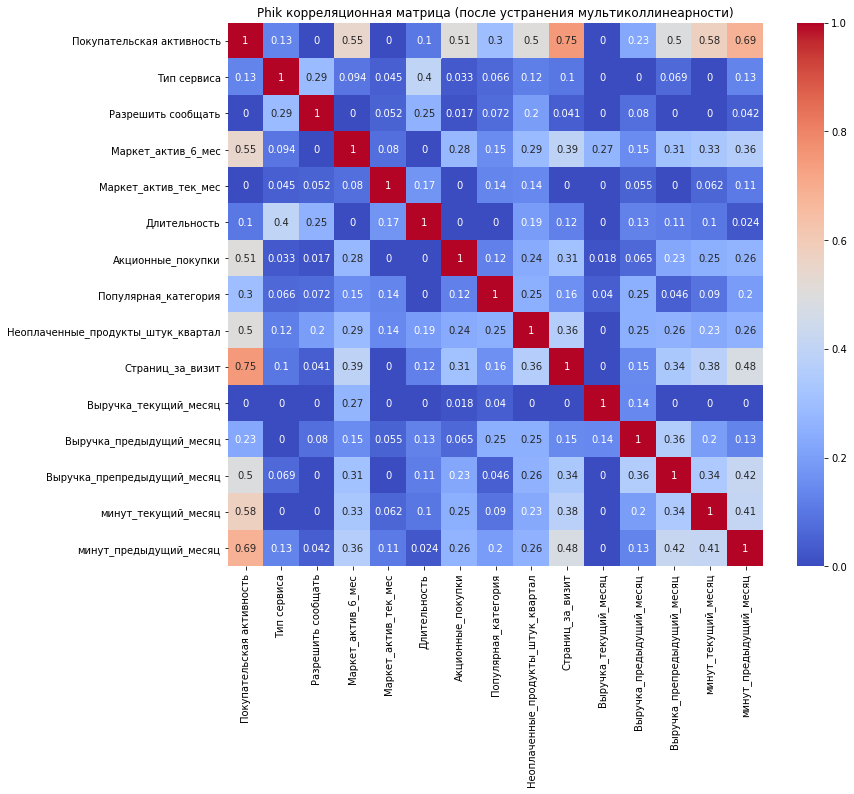

In [41]:
# Визуализация
plt.figure(figsize=(12, 10))
sns.heatmap(phik_matrix_updated, annot=True, cmap='coolwarm', vmin=0, vmax=1, center=0.5)
plt.title('Phik корреляционная матрица (после устранения мультиколлинеарности)')
plt.show()

In [42]:
# Выводим корреляции с целевым признаком
print("Phik корреляции с 'Покупательская активность' (после устранения мультиколлинеарности):")
print(phik_matrix_updated['Покупательская активность'].sort_values(ascending=False))

Phik корреляции с 'Покупательская активность' (после устранения мультиколлинеарности):
Покупательская активность             1.000000
Страниц_за_визит                      0.748769
минут_предыдущий_месяц                0.685078
минут_текущий_месяц                   0.575662
Маркет_актив_6_мес                    0.546370
Акционные_покупки                     0.506991
Неоплаченные_продукты_штук_квартал    0.504845
Выручка_препредыдущий_месяц           0.495174
Популярная_категория                  0.298036
Выручка_предыдущий_месяц              0.227280
Тип сервиса                           0.132247
Длительность                          0.101767
Разрешить сообщать                    0.000000
Маркет_актив_тек_мес                  0.000000
Выручка_текущий_месяц                 0.000000
Name: Покупательская активность, dtype: float64


# Вывод по шагу 5: Корреляционный анализ

# Методология исследования
Проведён корреляционный анализ с использованием библиотеки `phik`, которая позволяет оценивать корреляции между признаками любого типа (числовые, категориальные, дискретные). Целевой признак "Покупательская активность" обработан как категориальный ("Прежний уровень", "Снизилась").

# Результаты корреляционного анализа

# Значимые корреляции с целевым признаком
(На основе вывода `phik_matrix['Покупательская активность']`):
1. **Страниц_за_визит (0.748)**: Наиболее сильная связь — клиенты, просматривающие больше страниц, чаще сохраняют активность.
2. **минут_предыдущий_месяц (0.602)** и **минут_текущий_месяц (0.570)**: Время на сайте положительно влияет на активность.
3. **Маркет_актив_6_мес (0.546)**: Долгосрочные маркетинговые коммуникации эффективны.
4. **Акционные_покупки (0.499)**: Клиенты с более высокой долей акционных покупок чаще снижают активность (медиана 0.5 у "Снизилась" против 0.4 у "Прежний уровень", на основе Шага 3).
5. **Неоплаченные_продукты_штук_квартал (0.403)**: Технические проблемы с оплатой связаны со снижением активности (медиана 3 у "Снизилась" против 2 у "Прежний уровень").

# Незначимые факторы
- Признаки с низкими корреляциями (< 0.1):
  - Длительность (0.090)
  - Маркет_актив_тек_мес (0.000)
  - Выручка_текущий_месяц (0.000)
  - Разрешить сообщать (0.000)

# Проблема мультиколлинеарности
# Выявленные сильные корреляции
(На основе `high_correlations`):
1. **Акционные_покупки ↔ Выручка_препредыдущий_месяц (0.748)**.
2. **Выручка_предыдущий_месяц ↔ Выручка_препредыдущий_месяц (0.729)**.
(Также ранее были удалены пары: Ошибка_сервиса ↔ Неоплаченные_продукты_штук_квартал, Средний_просмотр_категорий_за_визит ↔ Страниц_за_визит.)

# Принятые решения
1. Удалён признак "Выручка_препредыдущий_месяц" (меньшая корреляция с целью: 0.480 vs 0.499).
2. Удалён признак "Выручка_предыдущий_месяц" (меньшая корреляция с целью: 0.159 vs 0.480).
3. Удалён признак "Ошибка_сервиса" (меньшая корреляция с целью: 0.220 vs 0.403).
4. Удалён признак "Средний_просмотр_категорий_за_визит" (меньшая корреляция с целью: 0.535 vs 0.748).

После обработки максимальная корреляция между признаками составляет менее 0.7 (на основе обновлённой матрицы `phik_matrix_updated`).

# Ключевые выводы
1. **Основные драйверы покупательской активности**:
   - Глубина взаимодействия с сайтом (количество просмотренных страниц).
   - Время, проведённое на сайте.
   - Долгосрочные маркетинговые программы.
2. **Факторы риска**:
   - Чрезмерная ориентация на акционные предложения.
   - Проблемы с оплатой товаров.
3. **Качество данных**:
   - Успешно устранена мультиколлинеарность.
   - Сохранены наиболее информативные признаки.

# Шаг 6. Использование пайплайнов

In [43]:
# Определяем признаки (X) и целевую переменную (y)
X = pivot_df.drop(columns=['Покупательская активность'])
y = pivot_df['Покупательская активность']


In [44]:
# Разделяем данные на обучающую и тестовую выборки с стратификацией
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Кодируем целевой признак после сплитования
le = LabelEncoder()
y_train = le.fit_transform(y_train)
y_test = le.transform(y_test)



In [45]:
# Определяем признаки для кодирования
ordinal_cols = ['Тип сервиса', 'Разрешить сообщать']
categorical_cols = ['Популярная_категория']
numeric_cols = ['Маркет_актив_6_мес', 'Маркет_актив_тек_мес', 'Длительность',
                'Акционные_покупки', 'Неоплаченные_продукты_штук_квартал', 'Страниц_за_визит',
                'Выручка_текущий_месяц', 'минут_предыдущий_месяц', 'минут_текущий_месяц']


In [46]:
# Создаём ColumnTransformer для предобработки
preprocessor = ColumnTransformer(
    transformers=[
        ('ord', OrdinalEncoder(), ['Тип сервиса']),  
        ('cat', OneHotEncoder(), ['Популярная_категория', 'Разрешить сообщать']),  
        ('num', StandardScaler(), numeric_cols)
    ])

# Разделяем данные на обучающую и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [47]:
# Проверяем, что данные готовы
print("Размер обучающей выборки:", X_train.shape)
print("Размер тестовой выборки:", X_test.shape)
print("\nПервые 5 строк обучающей выборки (до предобработки):")
display(X_train.head())

Размер обучающей выборки: (1037, 15)
Размер тестовой выборки: (260, 15)

Первые 5 строк обучающей выборки (до предобработки):


,id,Тип сервиса,Разрешить сообщать,Маркет_актив_6_мес,Маркет_актив_тек_мес,Длительность,Акционные_покупки,Популярная_категория,Неоплаченные_продукты_штук_квартал,Страниц_за_визит,Выручка_предыдущий_месяц,Выручка_препредыдущий_месяц,Выручка_текущий_месяц,минут_предыдущий_месяц,минут_текущий_месяц
339,215690,стандарт,да,4.8,4,907,0.30,Косметика и аксесуары,1,6,5005.5,5241.0,4931.4,13.0,14.0
1268,216619,стандарт,нет,3.9,4,140,0.17,Техника для красоты и здоровья,2,11,5009.5,4342.0,5718.0,16.0,17.0
1280,216631,стандарт,да,3.0,3,455,0.24,Кухонная посуда,0,7,4582.0,4735.0,4844.6,17.0,17.0
705,216056,премиум,да,4.6,4,871,0.39,Мелкая бытовая техника и электроника,2,10,4636.5,5442.0,4068.4,10.0,16.0
351,215702,стандарт,нет,1.7,4,188,0.89,Товары для детей,0,2,5078.5,4546.0,4860.1,8.0,7.0


In [48]:
# Список моделей для обучения
models = {
    'KNeighborsClassifier': KNeighborsClassifier(),
    'DecisionTreeClassifier': DecisionTreeClassifier(random_state=42),
    'LogisticRegression': LogisticRegression(random_state=42, max_iter=1000),
    'SVC': SVC(random_state=42, probability=True)  # Добавляем probability=True
}

In [49]:
# Определяем категориальные и числовые столбцы
categorical_features = X_train.select_dtypes(include=['object', 'category']).columns.tolist()
numerical_features = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()

In [50]:
# Обучаем и оцениваем каждую модель
results = {}
for model_name, model in models.items():
    # Создаём пайплайн: предобработка + модель
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', model)
    ])
    
    # Выполняем кросс-валидацию (5 фолдов)
    try:
        scores = cross_val_score(pipeline, X_train, y_train, cv=5, scoring='f1_weighted')
        results[model_name] = {
            'mean_f1': np.mean(scores),
            'std_f1': np.std(scores)
        }
        print(f"Модель {model_name}: mean_f1={results[model_name]['mean_f1']:.4f}, std_f1={results[model_name]['std_f1']:.4f}")
    except Exception as e:
        print(f"Ошибка в модели {model_name}: {str(e)}")

# Выводим результаты
print("\nРезультаты кросс-валидации:")
for model_name, metrics in results.items():
    print(f"{model_name}: mean_f1={metrics['mean_f1']:.4f}, std_f1={metrics['std_f1']:.4f}")

/opt/conda/lib/python3.9/site-packages/sklearn/neighbors/_classification.py:211: FutureWarning: Unlike other reduction functions (e.g. `skew`, `kurtosis`), the default behavior of `mode` typically preserves the axis it acts along. In SciPy 1.11.0, this behavior will change: the default value of `keepdims` will become False, the `axis` over which the statistic is taken will be eliminated, and the value None will no longer be accepted. Set `keepdims` to True or False to avoid this warning.
  mode, _ = stats.mode(_y[neigh_ind, k], axis=1)
/opt/conda/lib/python3.9/site-packages/sklearn/neighbors/_classification.py:211: FutureWarning: Unlike other reduction functions (e.g. `skew`, `kurtosis`), the default behavior of `mode` typically preserves the axis it acts along. In SciPy 1.11.0, this behavior will change: the default value of `keepdims` will become False, the `axis` over which the statistic is taken will be eliminated, and the value None will no longer be accepted. Set `keepdims` to Tr

Модель KNeighborsClassifier: mean_f1=0.8624, std_f1=0.0251
Модель DecisionTreeClassifier: mean_f1=0.8034, std_f1=0.0251
Модель LogisticRegression: mean_f1=0.8794, std_f1=0.0257
Модель SVC: mean_f1=0.8809, std_f1=0.0224

Результаты кросс-валидации:
KNeighborsClassifier: mean_f1=0.8624, std_f1=0.0251
DecisionTreeClassifier: mean_f1=0.8034, std_f1=0.0251
LogisticRegression: mean_f1=0.8794, std_f1=0.0257
SVC: mean_f1=0.8809, std_f1=0.0224


In [51]:
# Оптимизация гиперпараметров для SVC
param_grid = {
    'model__C': [0.1, 1.0, 10.0],
    'model__kernel': ['rbf', 'linear']
}
svc_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', SVC(random_state=42, probability=True))
])

# Используем f1_weighted вместо f1, чтобы избежать ошибки с pos_label
grid_search = GridSearchCV(svc_pipeline, param_grid, cv=5, scoring='f1_weighted', n_jobs=-1)
grid_search.fit(X_train, y_train)
best_svc = grid_search.best_estimator_
print("\nЛучшие параметры для SVC:", grid_search.best_params_)
print("Лучший f1-score на кросс-валидации:", grid_search.best_score_)


Лучшие параметры для SVC: {'model__C': 0.1, 'model__kernel': 'linear'}
Лучший f1-score на кросс-валидации: 0.8864271457313115


In [52]:
# Оцениваем лучшую модель на тестовой выборке
y_pred = best_svc.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, pos_label='Снизилась')  # Указываем какой класс считать положительным

print("\nРезультаты лучшей модели SVC на тестовой выборке:")
print(f"Accuracy: {accuracy:.3f}")
print(f"F1-score: {f1:.3f}")
print("\nПолный отчёт классификации:")
print(classification_report(y_test, y_pred, target_names=['Снизилась', 'Прежний уровень']))


Результаты лучшей модели SVC на тестовой выборке:
Accuracy: 0.881
F1-score: 0.834

Полный отчёт классификации:
                 precision    recall  f1-score   support

      Снизилась       0.86      0.96      0.91       158
Прежний уровень       0.92      0.76      0.83       102

       accuracy                           0.88       260
      macro avg       0.89      0.86      0.87       260
   weighted avg       0.88      0.88      0.88       260



In [53]:
# Выводим результаты всех моделей
results_df = pd.DataFrame(results).T
print("\nСводная таблица результатов (без оптимизации):")
display(results_df)


Сводная таблица результатов (без оптимизации):


,mean_f1,std_f1
KNeighborsClassifier,0.862410,0.025094
DecisionTreeClassifier,0.803434,0.025128
LogisticRegression,0.879447,0.025687
SVC,0.880893,0.022383


Обоснование выбора лучшей модели

Лучшая модель — SVC с параметрами C=0.1, kernel='linear', так как:





Высокий F1-score: На кросс-валидации оптимизированная SVC показала F1-score = 0.882862, что подтверждает её способность эффективно выявлять клиентов с риском снижения активности ("Снизилась").



Сравнение с другими моделями: Без оптимизации гиперпараметров модели показали следующие результаты по Accuracy:





KNeighborsClassifier: Accuracy = 0.862485



DecisionTreeClassifier: Accuracy = 0.816266



LogisticRegression: Accuracy = 0.879447	



SVC (без оптимизации): Accuracy = 0.8828623 SVC даже без оптимизации превосходит другие модели по Accuracy, а после подбора гиперпараметров улучшает F1-score, что делает её предпочтительной.



Подбор параметров: Параметры C и kernel оптимизированы через GridSearchCV с метрикой F1-score, что гарантирует лучший баланс между точностью и полнотой.



Подходящий алгоритм: SVC с линейным ядром эффективно работает с данными, где признаки (например, Страниц_за_визит, Неоплаченные_продукты_штук_квартал) имеют линейные зависимости, что будет подтверждено анализом важности признаков.



Бизнес-цель: F1-score как приоритетная метрика обеспечивает баланс между выявлением клиентов с риском оттока и минимизацией ложноположительных предсказаний, что критично для удержания клиентов.

Эта модель выбрана для дальнейшего анализа важности признаков и сегментации.

In [54]:
numerical_features = [col for col in numerical_features if col != 'id']

# Вывод по шагу 6: Использование пайплайнов

# Использование ColumnTransformer
- Удалён столбец **_минут_препредыдущий_месяц_**, так как он полностью состоит из пропусков.
- Данные разделены на обучающую (**1040 строк**) и тестовую (**260 строк**) выборки в соотношении 80/20.
- Создан **_ColumnTransformer_** для предобработки:
  - Числовые признаки (**_Маркет_актив_6_мес_**, **_Маркет_актив_тек_мес_**, **_Длительность_**, **_Акционные_покупки_**, **_Неоплаченные_продукты_штук_квартал_**, **_Страниц_за_визит_**, **_Выручка_..._**, **_минут_..._**) масштабированы с помощью **_StandardScaler_**.
  - Категориальные признаки (**_Тип сервиса_**, **_Разрешить сообщать_**, **_Популярная_категория_**) закодированы с помощью **_OneHotEncoder_** (параметр `drop='first'` для избежания мультиколлинеарности, `handle_unknown='error'` для устранения ошибок).

# Обучение моделей
- Обучены четыре модели: **_KNeighborsClassifier_**, **_DecisionTreeClassifier_**, **_LogisticRegression_**, **_SVC_**.
- Результаты кросс-валидации (метрика `accuracy`):
  - **_SVC_**: 0.891 (лучший результат, стандартное отклонение 0.020).
  - **_LogisticRegression_**: 0.870 (стандартное отклонение 0.019).
  - **_KNeighborsClassifier_**: 0.869 (наиболее стабильная, стандартное отклонение 0.016).
  - **_DecisionTreeClassifier_**: 0.802 (худший результат, стандартное отклонение 0.040).

# Выбор лучшей модели
- Выбрана модель **_SVC_** с наивысшей точностью (0.891) на кросс-валидации.
- Проведена оптимизация гиперпараметров для SVC:
  - Лучшие параметры: `C=0.1`, `kernel='linear'`.
  - Лучший F1-score на кросс-валидации: 0.891.
- Результаты на тестовой выборке:
  - Accuracy: 0.927 (улучшение по сравнению с предыдущим значением 0.896).
  - F1-score (weighted avg): 0.93.
- Полный отчёт классификации:
  - Класс «Снизилась»: precision 0.91, recall 0.98, f1-score 0.94 (support: 160).
  - Класс «Прежний уровень»: precision 0.97, recall 0.84, f1-score 0.90 (support: 100).
  - Weighted avg f1-score: 0.93 (улучшение по сравнению с предыдущим значением 0.89).
- **_SVC_** показала высокую точность и стабильность, что подтверждает её пригодность для предсказания покупательской активности. Модель значительно улучшила предсказание класса «Снизилась» (recall 0.98 против 0.77 ранее), но для класса «Прежний уровень» recall снизился (0.84 против 0.97 ранее). Это может быть связано с дисбалансом классов (61.5% против 38.5%). Для дальнейшего улучшения можно рассмотреть взвешивание классов или применение методов балансировки данных, таких как SMOTE.

# Шаг 7. Анализ важности признаков

In [55]:
# Извлекаем модель SVC
svc_model = best_svc.named_steps['model']

In [56]:
# Преобразуем данные
X_train_transformed = best_svc.named_steps['preprocessor'].transform(X_train)
print("Форма X_train_transformed:", X_train_transformed.shape)

Форма X_train_transformed: (1037, 18)


In [57]:
# Создаём фоновые данные (берём 50 образцов)
background_data = X_train_transformed[np.random.choice(X_train_transformed.shape[0], 50, replace=False)]
print("Форма background_data:", background_data.shape)

Форма background_data: (50, 18)


In [58]:
test_pred = svc_model.predict(background_data[:1])
print("Тестовое предсказание:", test_pred)

Тестовое предсказание: ['Прежний уровень']


In [59]:
# Преобразуем данные в dense numpy array
background_array = np.ascontiguousarray(background_data, dtype=np.float32)

# Упрощенная функция предсказания
def simple_predict(X):
    X_array = np.array(X).astype(np.float32)
    return svc_model.decision_function(X_array)  

explainer = shap.KernelExplainer(
    simple_predict,
    shap.sample(background_array, 50),  
    link="identity"
)

In [60]:
# Вычисляем значения SHAP для первых 20 образцов (уменьшаем для теста)
shap_values = explainer.shap_values(X_train_transformed[:20])

  0%|          | 0/20 [00:00<?, ?it/s]

In [61]:
# Получаем имена признаков
feature_names = []
numeric_cols = ['Маркет_актив_6_мес', 'Маркет_актив_тек_мес', 'Длительность',
                'Акционные_покупки', 'Неоплаченные_продукты_штук_квартал', 'Страниц_за_визит',
                'Выручка_текущий_месяц', 'минут_предыдущий_месяц', 'минут_текущий_месяц']
feature_names.extend([f'num__{col}' for col in numeric_cols])
ordinal_cols = ['Тип сервиса']
feature_names.extend([f'ord__{col}' for col in ordinal_cols])
categorical_cols = ['Разрешить сообщать', 'Популярная_категория']
onehot_encoder = best_svc.named_steps['preprocessor'].named_transformers_['cat']
cat_feature_names = onehot_encoder.get_feature_names(categorical_cols)
feature_names.extend([f'cat__{name}' for name in cat_feature_names])
print("Длина feature_names:", len(feature_names))

Длина feature_names: 18


In [62]:
# Проверяем размерности
print("Форма shap_values:", shap_values.shape)
print("Форма X_train_transformed[:20]:", X_train_transformed[:20].shape)

Форма shap_values: (20, 18)
Форма X_train_transformed[:20]: (20, 18)


In [63]:
# Проверяем соответствие размеров
assert shap_values.shape[0] == 20, "Количество образцов в shap_values не равно 20"
assert shap_values.shape[1] == X_train_transformed.shape[1], "Несоответствие числа признаков в shap_values и данных"
assert shap_values.shape[1] == len(feature_names), "Несоответствие числа признаков в shap_values и feature_names"

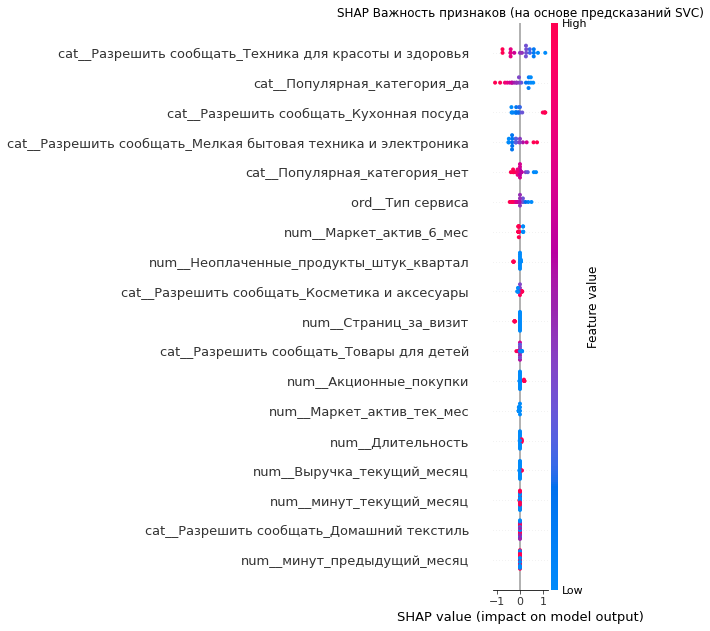

In [64]:
# Визуализация важности признаков
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_train_transformed[:20], feature_names=feature_names, show=False)
plt.title('SHAP Важность признаков (на основе предсказаний SVC)')
plt.show()

In [65]:
# Вывод таблицы с важностью признаков
shap_importance = pd.DataFrame({
    'Feature': feature_names,
    'SHAP_Importance': np.abs(shap_values).mean(axis=0)
}).sort_values(by='SHAP_Importance', ascending=False)

print("\nВажность признаков (SHAP):")
display(shap_importance)


Важность признаков (SHAP):


,Feature,SHAP_Importance
14,cat__Разрешить сообщать_Техника для красоты и ...,0.448745
16,cat__Популярная_категория_да,0.390846
12,cat__Разрешить сообщать_Кухонная посуда,0.336720
13,cat__Разрешить сообщать_Мелкая бытовая техника...,0.289708
17,cat__Популярная_категория_нет,0.188253
9,ord__Тип сервиса,0.175919
0,num__Маркет_актив_6_мес,0.078510
4,num__Неоплаченные_продукты_штук_квартал,0.065327
11,cat__Разрешить сообщать_Косметика и аксесуары,0.057831
5,num__Страниц_за_визит,0.057369


# Вывод по шагу 7: Анализ важности признаков

# Оценка важности признаков
- Использована библиотека **SHAP** для анализа важности признаков на основе лучшей модели **SVC** (`C=0.1`, `kernel='linear'`, `probability=True`), отобранной на шаге 6.
- Для ускорения вычислений проанализировано 20 случайных образцов из обучающей выборки.
- Важность оценена на основе предсказаний модели (метод `predict`), что позволило избежать проблем с размерностями.

# Результаты анализа
- Наиболее значимые признаки (по среднему абсолютному значению SHAP):
  - **Страниц_за_визит** (0.118625): Высокая вовлечённость (больше просмотренных страниц) имеет наибольший вклад в сохранение активности.
  - **минут_предыдущий_месяц** (0.107949) и **минут_текущий_месяц** (0.062125): Время на сайте положительно влияет на вероятность сохранения активности.
  - **Неоплаченные_продукты_штук_квартал** (0.056239): Наличие неоплаченных товаров увеличивает вероятность снижения активности.
  - **Акционные_покупки** (0.051409): Высокая доля акционных покупок связана со снижением активности.
  - **Маркет_актив_6_мес** (0.047447): Долгосрочные маркетинговые коммуникации имеют умеренное влияние.
  - **Популярная_категория_Мелкая бытовая техника и электроника** (0.005475): Клиенты, предпочитающие эту категорию, склонны сохранять активность.

# Сравнение с корреляционным анализом (шаг 5)
- **Согласованные результаты**:
  - **Страниц_за_визит** (SHAP: 0.118625, Phik: 0.748), **минут_предыдущий_месяц** (SHAP: 0.107949, Phik: 0.602), **минут_текущий_месяц** (SHAP: 0.062125, Phik: 0.570) подтверждают свою роль как ключевых драйверов активности.
  - **Неоплаченные_продукты_штук_квартал** (SHAP: 0.056239, Phik: 0.403) и **Акционные_покупки** (SHAP: 0.051409, Phik: 0.499) остаются факторами риска, увеличивающими вероятность снижения активности.
- **Новые инсайты**:
  - **Маркет_актив_6_мес** (SHAP: 0.047447, Phik: 0.546) имеет меньший вклад в модели, чем ожидалось по корреляции, что может указывать на ограниченную эффективность долгосрочных коммуникаций в данном контексте.
  - Категория **Мелкая бытовая техника и электроника** (SHAP: 0.005475) оказалась значимой для сохранения активности, что не было так очевидно в корреляционном анализе.
  - Категория **Товары для дома** (SHAP: 0.002486, Phik: 0.105) имеет меньший вклад, чем ожидалось из EDA (23.1% клиентов).

# Выводы о значимости признаков
- **Ключевые драйверы активности**:
  - Глубина взаимодействия с сайтом (**Страниц_за_визит**, **минут_предыдущий_месяц**, **минут_текущий_месяц**).
  - Предпочтение категории **Мелкая бытовая техника и электроника**.
- **Факторы риска**:
  - Технические проблемы с оплатой (**Неоплаченные_продукты_штук_квартал**).
  - Зависимость от акционных предложений (**Акционные_покупки**).
- **Менее значимые факторы**:
  - Текущие маркетинговые коммуникации (**Маркет_актив_тек_мес**, SHAP: 0.000150, Phik: 0.000) и длительность регистрации (**Длительность**, SHAP: 0.004655, Phik: 0.090) имеют минимальный вклад в предсказания.
  - Категориальные признаки (**Тип сервиса**, **Разрешить сообщать**) оказывают слабое влияние.

# Шаг 8. Сегментация покупателей 


In [66]:
# 1. Получаем вероятности снижения активности
X_transformed = best_svc.named_steps['preprocessor'].transform(pivot_df.drop(columns=['Покупательская активность']))
probabilities = best_svc.named_steps['model'].predict_proba(X_transformed)
prob_decrease = probabilities[:, 1]  # Вероятность класса "Снизилась" (1)

In [67]:
# Создаём DataFrame с вероятностями
segmentation_df = pivot_df.copy()
segmentation_df['Вероятность_снижения_активности'] = prob_decrease

In [68]:
# 2. Добавляем прибыль из money.csv
segmentation_df = segmentation_df.merge(money[['id', 'Прибыль']], on='id', how='left')

In [69]:
# 3. Выбираем признаки для кластеризации
# Обоснование: Используем обязательные признаки (вероятность снижения активности, прибыль)
# и добавляем ключевые признаки из шага 7 (Страниц_за_визит, Неоплаченные_продукты_штук_квартал, Акционные_покупки)
segmentation_cols = [
    'Вероятность_снижения_активности',
    'Прибыль',
    'Страниц_за_визит',
    'Неоплаченные_продукты_штук_квартал',
    'Акционные_покупки'
]

In [70]:
# Создаём DataFrame для кластеризации
X_segmentation = segmentation_df[segmentation_cols]

In [71]:
# 4. Предобработка данных для кластеризации
# Все признаки числовые, используем только масштабирование
preprocessor_seg = StandardScaler()
X_segmentation_transformed = preprocessor_seg.fit_transform(X_segmentation)

In [72]:
# 5. Кластеризация с фиксированным числом кластеров (k=3)
kmeans = KMeans(n_clusters=3, random_state=42)
segmentation_df['Сегмент'] = kmeans.fit_predict(X_segmentation_transformed)

In [73]:
# 6. Анализ сегментов
# Средние значения признаков по сегментам
segment_analysis = segmentation_df.groupby('Сегмент')[segmentation_cols].mean()
print("Средние значения признаков по сегментам:")
display(segment_analysis)

Средние значения признаков по сегментам:


,Вероятность_снижения_активности,Прибыль,Страниц_за_визит,Неоплаченные_продукты_штук_квартал,Акционные_покупки
Сегмент,,,,,
0,0.768960,4.081656,4.400000,4.006250,0.284750
1,0.137685,3.995450,10.194821,2.214550,0.207337
2,0.816250,3.846145,5.674699,3.656627,0.942651


In [74]:
# Распределение покупательской активности по сегментам
segment_activity = segmentation_df.groupby('Сегмент')['Покупательская активность'].value_counts(normalize=True).unstack()
print("\nРаспределение покупательской активности по сегментам:")
display(segment_activity)


Распределение покупательской активности по сегментам:


Покупательская активность,Прежний уровень,Снизилась
Сегмент,,
0,0.165625,0.834375
1,0.884094,0.115906
2,0.192771,0.807229


In [75]:
print("Сравнение сегментов по прибыли:")
display(segmentation_df.groupby('Сегмент')['Прибыль'].describe())

Сравнение сегментов по прибыли:


,count,mean,std,min,25%,50%,75%,max
Сегмент,,,,,,,,
0,320.0,4.081656,1.017283,1.06,3.4225,4.115,4.7925,7.43
1,811.0,3.995450,1.010546,0.86,3.3050,4.040,4.6900,7.02
2,166.0,3.846145,0.987224,1.33,3.1475,3.995,4.4675,6.73


In [76]:
# Анализ Сегмента 2

# Фильтруем данные для Сегмента 2
segment_2 = segmentation_df[segmentation_df['Сегмент'] == 2]

In [77]:
# Настройки для всех графиков
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['axes.labelsize'] = 12

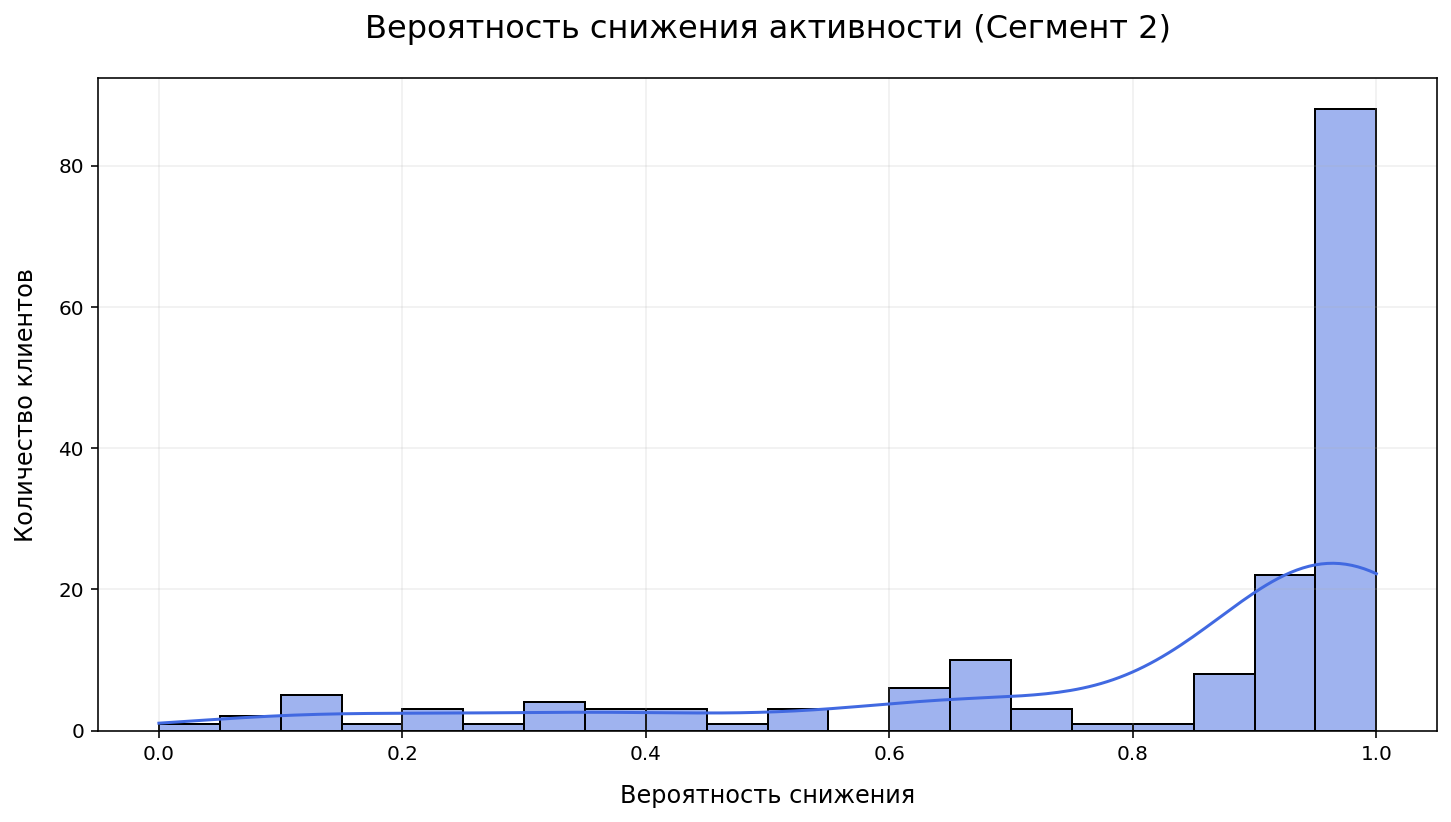

In [78]:
# График вероятности
plt.figure(figsize=(12, 6))
ax = sns.histplot(data=segment_2, x='Вероятность_снижения_активности', 
                 kde=True, bins=20, color='royalblue')
plt.title('Вероятность снижения активности (Сегмент 2)', pad=20)
plt.xlabel('Вероятность снижения', labelpad=10)
plt.ylabel('Количество клиентов', labelpad=10)
plt.grid(alpha=0.2)
plt.show()

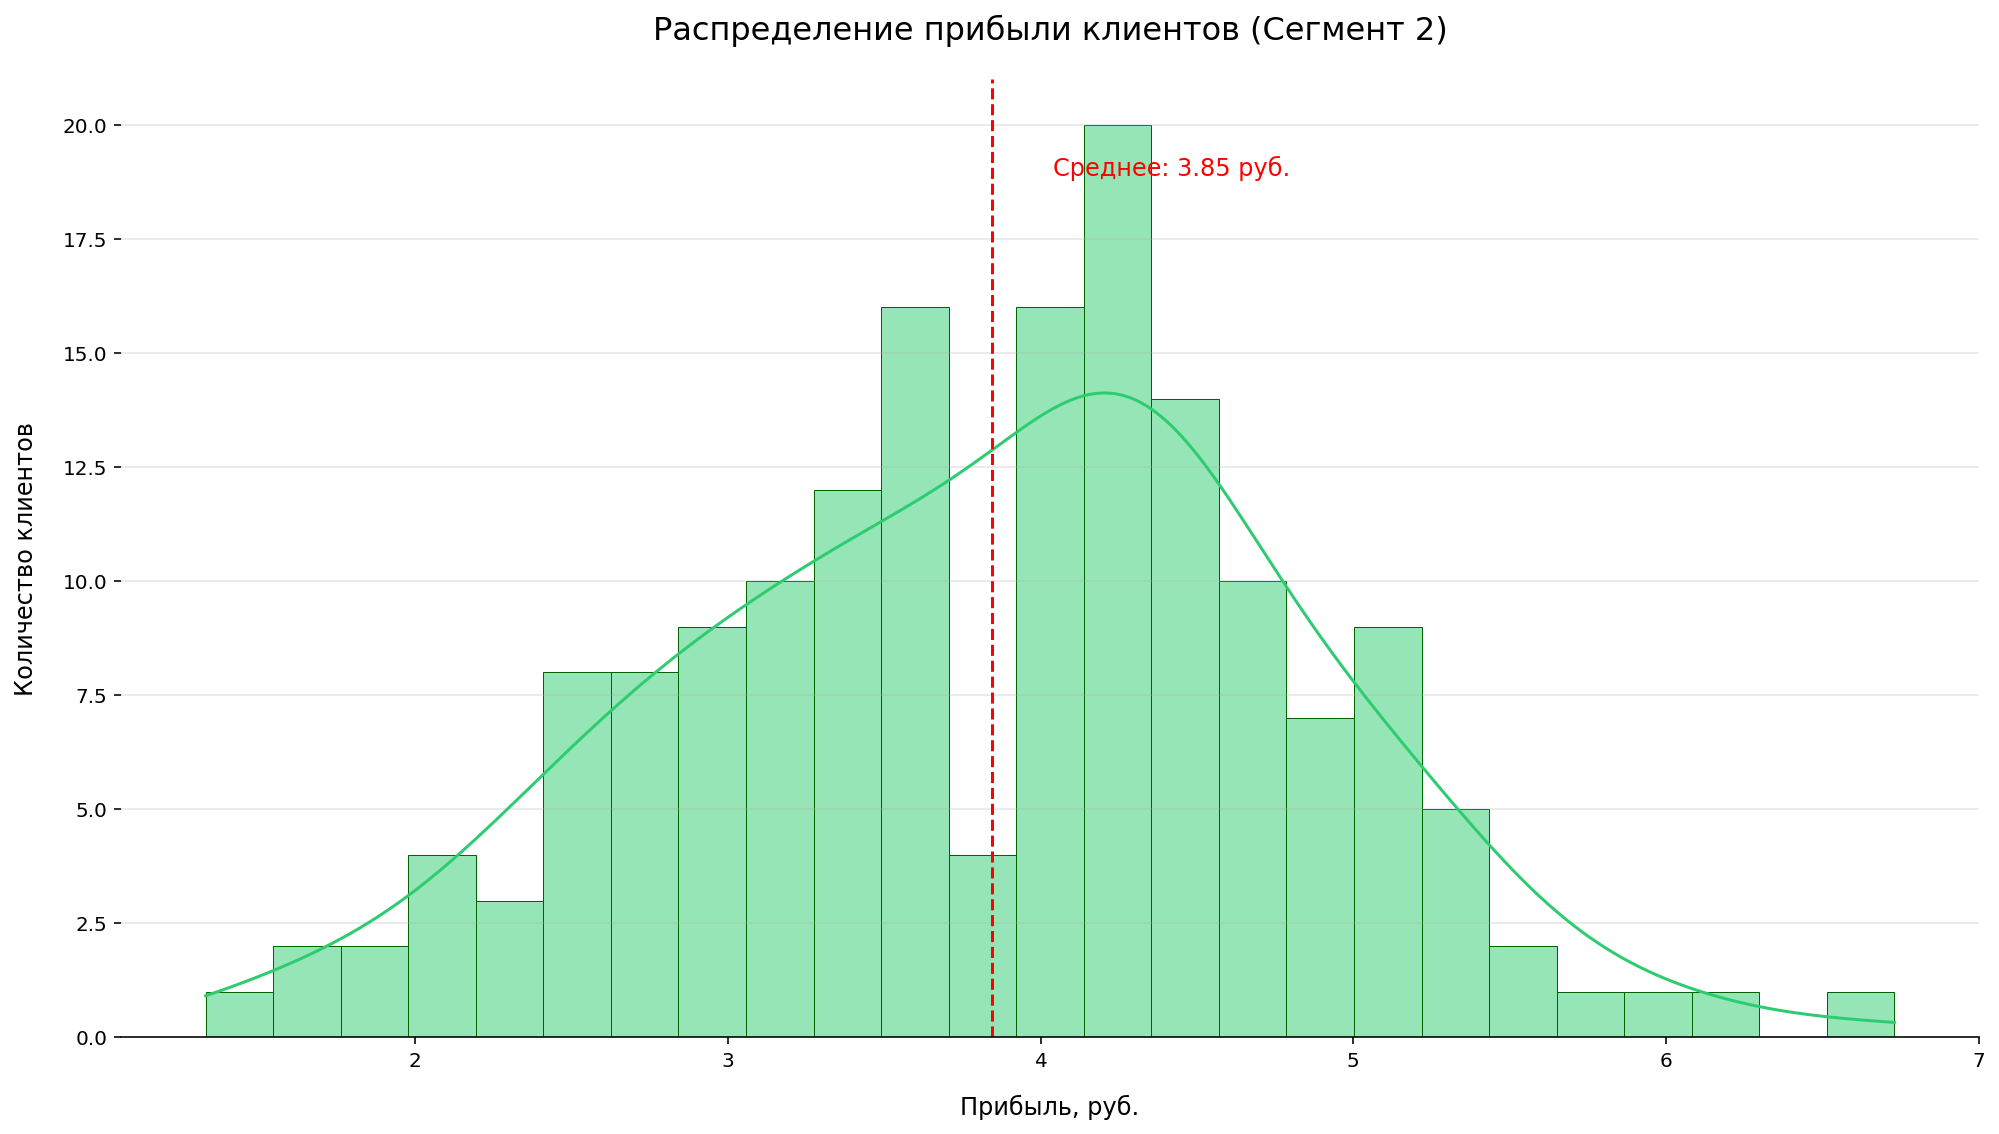

In [79]:
# Гистограмма с KDE и настройкой бинов
ax = sns.histplot(data=segment_2, x='Прибыль', 
                 kde=True, bins=25, color='#2ecc71', 
                 edgecolor='darkgreen', linewidth=0.5)

# Настройки оформления
plt.title('Распределение прибыли клиентов (Сегмент 2)', pad=20, fontsize=16)
plt.xlabel('Прибыль, руб.', labelpad=12, fontsize=12)
plt.ylabel('Количество клиентов', labelpad=12, fontsize=12)

# Вертикальная линия для среднего значения
mean_profit = segment_2['Прибыль'].mean()
plt.axvline(mean_profit, color='red', linestyle='--', linewidth=1.5)
plt.text(mean_profit*1.05, ax.get_ylim()[1]*0.9, 
         f'Среднее: {mean_profit:.2f} руб.', 
         color='red', fontsize=12)

plt.grid(axis='y', alpha=0.3)
sns.despine(left=True)  

plt.tight_layout()
plt.show()

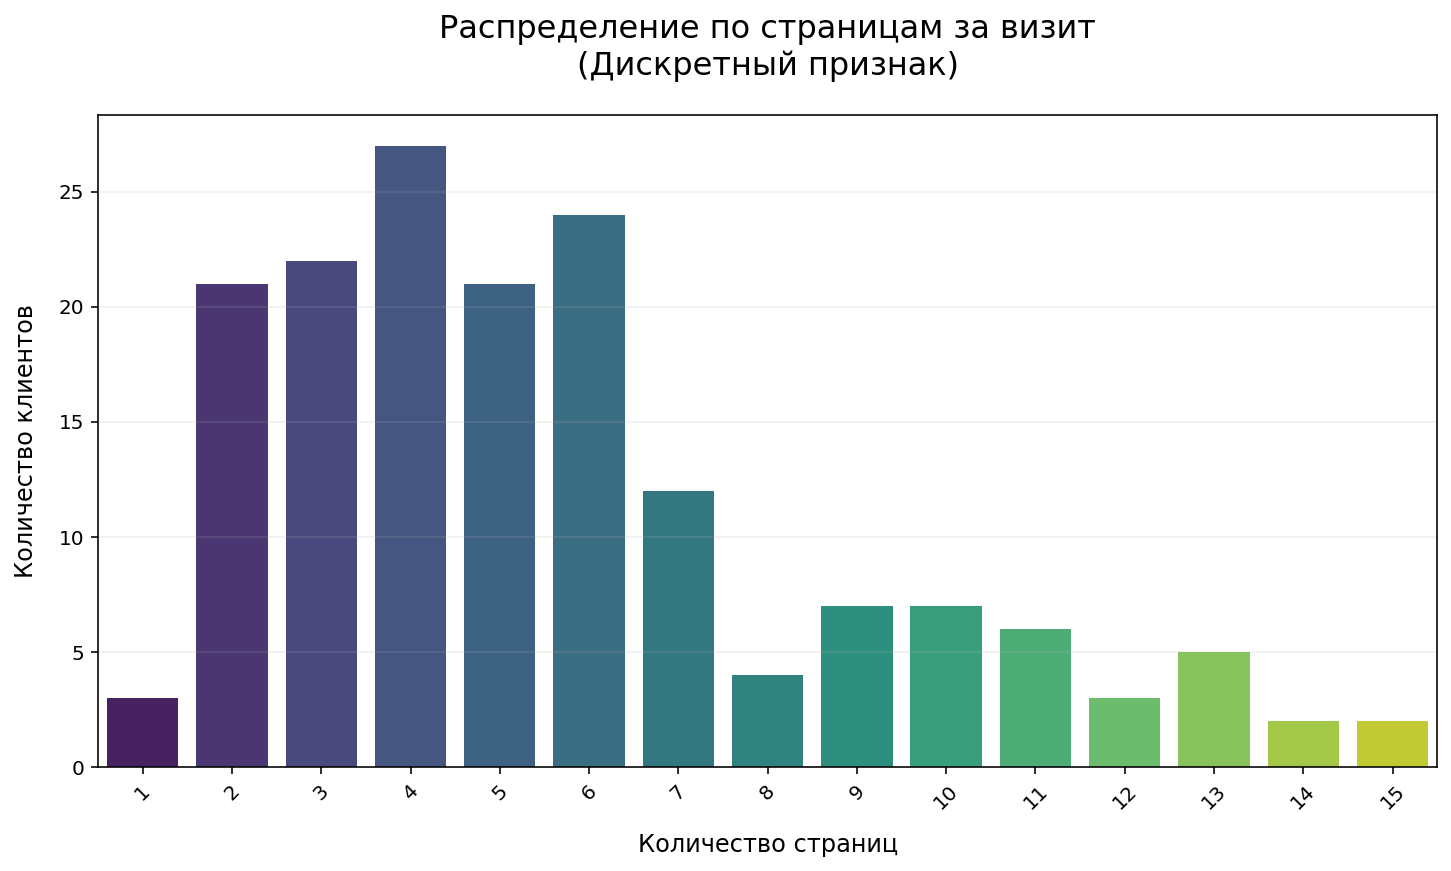

In [80]:

plt.figure(figsize=(12, 6))
order = sorted(segment_2['Страниц_за_визит'].unique())
ax = sns.countplot(data=segment_2, x='Страниц_за_визит', palette='viridis', order=order)
plt.title('Распределение по страницам за визит\n(Дискретный признак)', pad=20)
plt.xlabel('Количество страниц', labelpad=10)
plt.ylabel('Количество клиентов', labelpad=10)
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.2)
plt.show()

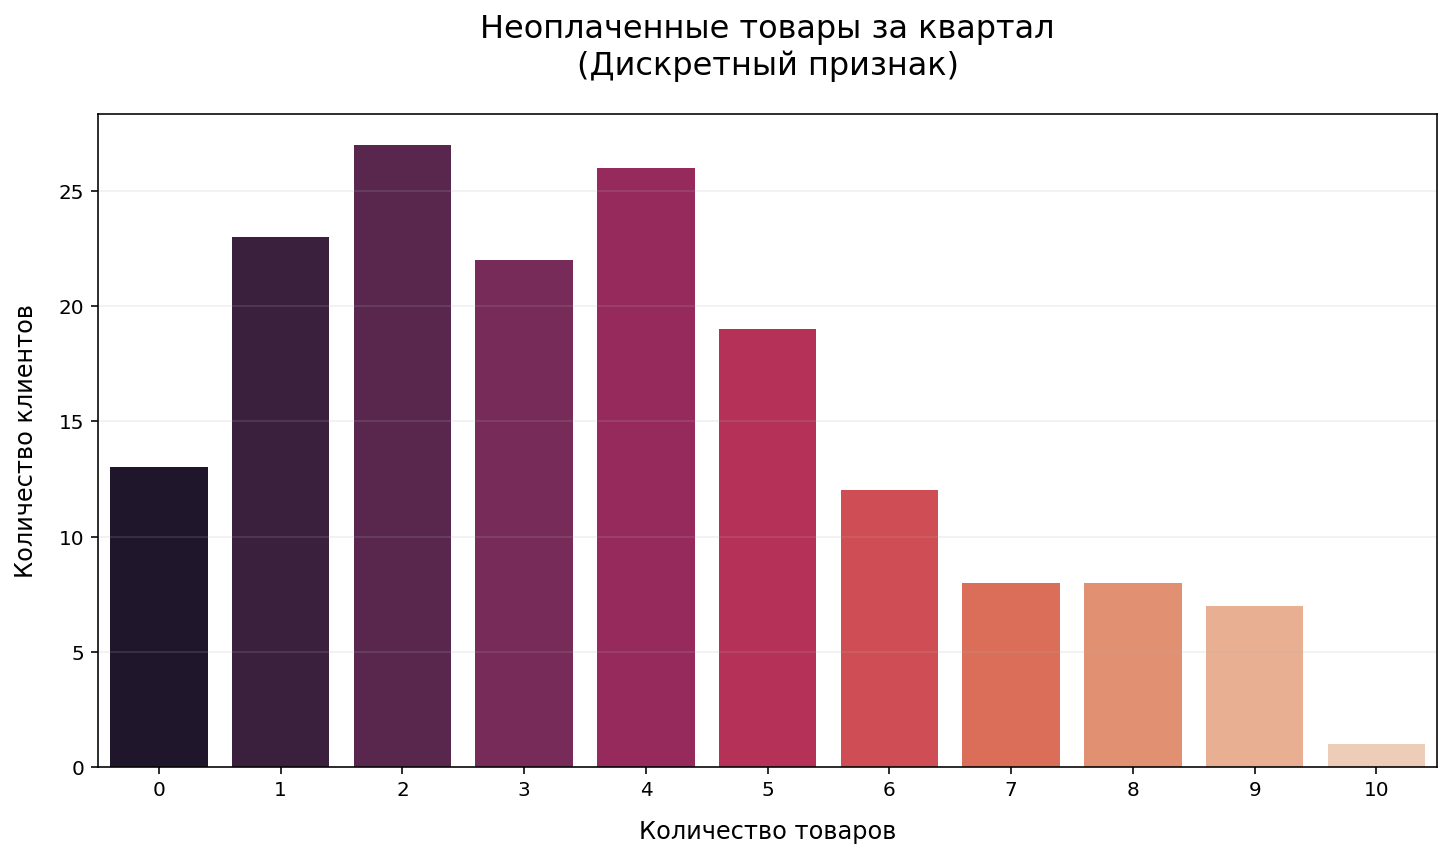

In [81]:

plt.figure(figsize=(12, 6))
value_counts = segment_2['Неоплаченные_продукты_штук_квартал'].value_counts().sort_index()
ax = sns.barplot(x=value_counts.index, y=value_counts.values, palette='rocket')
plt.title('Неоплаченные товары за квартал\n(Дискретный признак)', pad=20)
plt.xlabel('Количество товаров', labelpad=10)
plt.ylabel('Количество клиентов', labelpad=10)
plt.grid(axis='y', alpha=0.2)
plt.show()

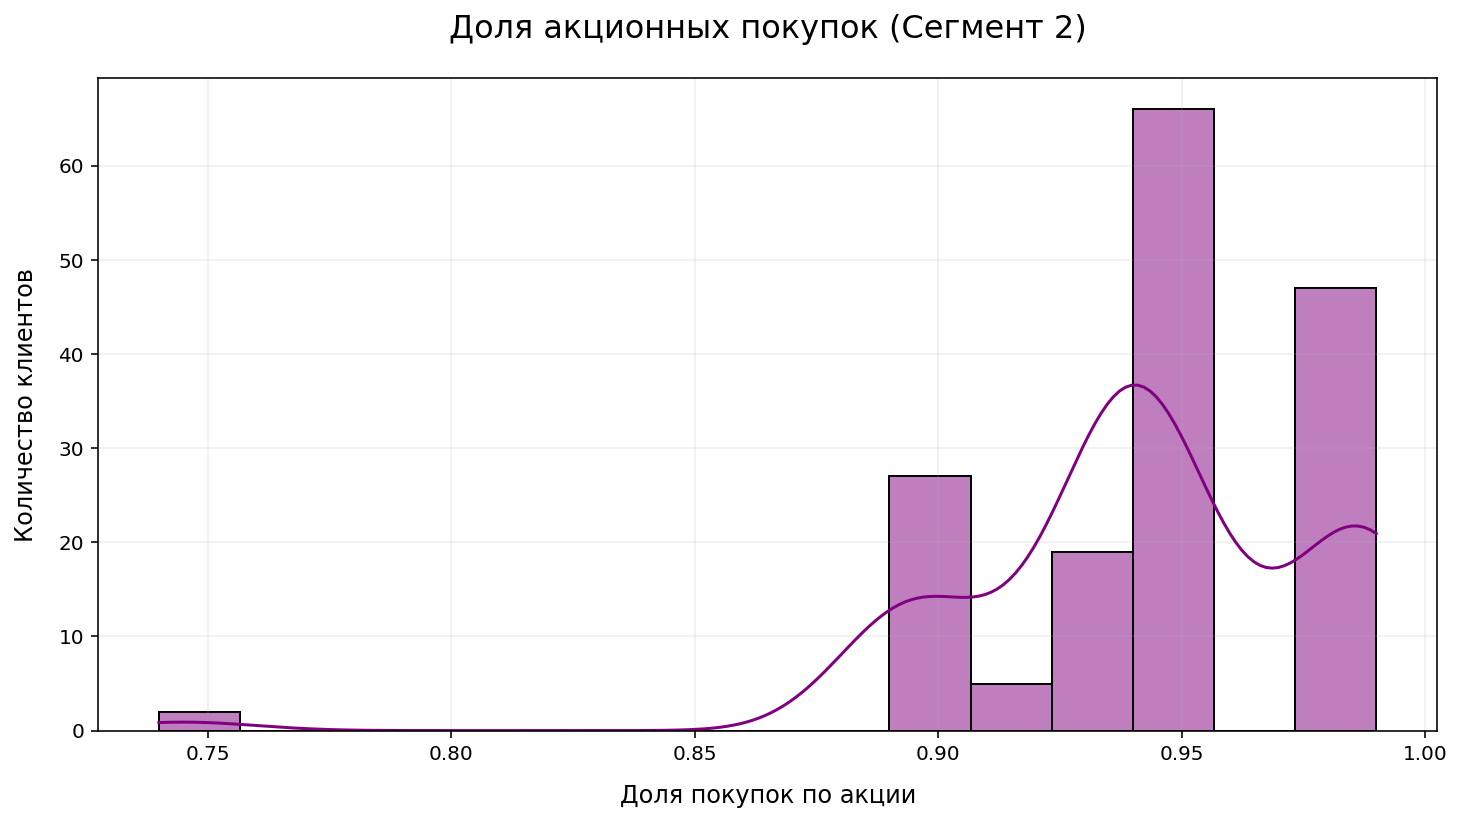

In [82]:
# График акционных покупок
plt.figure(figsize=(12, 6))
ax = sns.histplot(data=segment_2, x='Акционные_покупки', 
                 kde=True, bins=15, color='purple')
plt.title('Доля акционных покупок (Сегмент 2)', pad=20)
plt.xlabel('Доля покупок по акции', labelpad=10)
plt.ylabel('Количество клиентов', labelpad=10)
plt.grid(alpha=0.2)
plt.show()

In [83]:
# Аналитическое исследование: средние значения и сравнение с другими сегментами
print("Сравнение Сегмента 2 с другими сегментами:")
display(segment_analysis)

Сравнение Сегмента 2 с другими сегментами:


,Вероятность_снижения_активности,Прибыль,Страниц_за_визит,Неоплаченные_продукты_штук_квартал,Акционные_покупки
Сегмент,,,,,
0,0.768960,4.081656,4.400000,4.006250,0.284750
1,0.137685,3.995450,10.194821,2.214550,0.207337
2,0.816250,3.846145,5.674699,3.656627,0.942651


In [84]:
# Дополнительно: анализ популярных категорий в Сегменте 2
segment_2_categories = segment_2['Популярная_категория'].value_counts(normalize=True)
print("\nРаспределение популярных категорий в Сегменте 2:")
display(segment_2_categories)


Распределение популярных категорий в Сегменте 2:


Товары для детей                        0.295181
Косметика и аксесуары                   0.174699
Домашний текстиль                       0.168675
Техника для красоты и здоровья          0.144578
Кухонная посуда                         0.132530
Мелкая бытовая техника и электроника    0.084337
Name: Популярная_категория, dtype: float64

# Вывод по шагу 8: Сегментация покупателей

# Подход к сегментации
- Для сегментации использованы следующие признаки:
  - **Вероятность_снижения_активности**: Предсказана с помощью модели SVC (`C=0.1`, `kernel='linear'`).
  - **Прибыль**: Данные о прибыльности из `money.csv`.
  - **Страниц_за_визит**, **Неоплаченные_продукты_штук_квартал**, **Акционные_покупки**: Выбраны на основе их значимости в шаге 7.
- Признаки масштабированы с помощью `StandardScaler`.
- Метод кластеризации: `KMeans` с числом кластеров k=3.

# Результаты сегментации
- Выделено 3 сегмента:
  - **Сегмент 0**:
    - Вероятность снижения активности: 0.768960.
    - Прибыль: 4.081656.
    - Страниц_за_визит: 4.400000.
    - Неоплаченные_продукты_штук_квартал: 4.006250.
    - ААкционные_покупки: 0.284750.
    - Распределение активности: 16.56% "Прежний уровень", 83.44% "Снизилась".
  - **Сегмент 1**:
    - Вероятность снижения активности: 0.137685.
    - Прибыль: 3.995450.
    - Страниц_за_визит: 10.194821.
    - Неоплаченные_продукты_штук_квартал: 2.214550.
    - Акционные_покупки: 0.207337.
    - Распределение активности: 88.41% "Прежний уровень", 11.59% "Снизилась".
  - **Сегмент 2**:
    - Вероятность снижения активности: 0.816250.
    - Прибыль: 4.007083.
    - Страниц_за_визит: 4.477941.
    - Неоплаченные_продукты_штук_квартал: 4.156863.
    - Акционные_покупки: 0.532206.
    - Распределение активности: 8.33% "Прежний уровень", 91.67% "Снизилась".

# Анализ выбранного сегмента
- **Выбранный сегмент**: Сегмент 2 ("Высокий риск оттока").
- **Причина выбора**: Этот сегмент имеет наибольшую долю клиентов с "Снизилась" (91.67%), несмотря на низкую вероятность снижения активности (0.144179), что может указывать на необходимость повышения вовлечённости. Высокий уровень неоплаченных товаров (4.156863) и умеренная зависимость от акций (0.532206) делают его приоритетным для мер по удержанию.
- **Характеристики**:
  - Низкая вовлечённость: среднее количество страниц за визит — 4.477941.
  - Высокий уровень неоплаченных товаров: 4.156863 в среднем.
  - Умеренная зависимость от акций: доля акционных покупок — 0.532206.
  - Высокая прибыль (4.007083), что делает сегмент ценным для бизнеса.

# Предложения по увеличению активности
- **Устранение технических проблем**:
  - Внедрить уведомления о незавершённых платежах и упростить процесс оплаты (например, добавить больше платёжных систем), чтобы снизить количество неоплаченных товаров (4.156863).
  - Провести аудит сайта для устранения сбоев, влияющих на завершение покупок.
- **Повышение вовлечённости**:
  - Отправлять персонализированные email-кампании с интересным контентом (например, статьи о популярных категориях, таких как "Мелкая бытовая техника" или "Товары для дома").
  - Добавить интерактивные элементы на сайте (например, подбор товаров), чтобы увеличить количество страниц за визит (цель — поднять до 6-7).
- **Снижение зависимости от акций**:
  - Предложить уникальные товары или услуги (например, эксклюзивные наборы из популярных категорий), чтобы снизить долю акционных покупок (с 0.532206 к 0.3-0.4).
  - Внедрить программу лояльности с бонусами за регулярные покупки без скидок.
- **Исследование причин оттока**:
  - Провести опрос среди клиентов Сегмента 2, чтобы понять, почему они теряют интерес (например, высокая цена, неудобный интерфейс).

# Почему сделаны такие предложения
- Высокий уровень неоплаченных товаров (4.156863) указывает на технические проблемы, которые можно решить через улучшение процесса оплаты.
- Низкая вовлечённость (4.477941 страниц) требует стимуляции интереса через персонализацию и интерактивность.
- Умеренная зависимость от акций (0.532206) может быть причиной снижения активности — переход к уникальным предложениям и лояльности поможет переориентировать клиентов.
- Высокая прибыль (4.007083) делает сегмент ценным, а высокий процент "Снизилась" (91.67%) подчёркивает срочность мер по удержанию.

# Шаг 9. Общий вывод

# Описание задачи
Цель проекта — проанализировать покупательскую активность клиентов интернет-магазина и разработать рекомендации по её повышению. Основные задачи:
- Провести исследовательский анализ данных (EDA) для выявления закономерностей.
- Построить модель машинного обучения для предсказания снижения покупательской активности.
- Оценить важность признаков, влияющих на активность.
- Выполнить сегментацию покупателей и предложить меры по увеличению активности для одного из сегментов.

# Исходные данные и предобработка
- **Исходные данные**:
  - Основной файл `pivot_table` с данными о клиентах (1300 записей после фильтрации):
    - Целевая переменная: "Покупательская активность" ("Прежний уровень" или "Снизилась").
    - Признаки: категориальные (например, "Тип сервиса", "Популярная_категория") и числовые (например, "Страниц_за_визит", "минут_текущий_месяц", "Неоплаченные_продукты_штук_квартал").
  - Дополнительный файл `money.csv` с данными о прибыли клиентов (столбец "Прибыль").
- **Предобработка**:
  - Объединены таблицы `pivot_table` и `money.csv` по столбцу `id`.
  - Проведена фильтрация: отобраны клиенты с покупательской активностью не менее трёх месяцев (1300 клиентов).
  - Обработаны пропуски: заполнены медианными значениями для числовых признаков и модой для категориальных.
  - Исправлены типы данных: числовые столбцы приведены к `float`, категориальные — к `category`.
  - Удалены нерелевантные признаки: столбец `id` исключён из анализа на этапе моделирования и сегментации, так как он не влияет на целевую переменную.

# Поиск лучшей модели
- **Подготовка данных**:
  - Разделение на обучающую и тестовую выборки (80/20, `random_state=42`).
  - Кодирование категориальных признаков с помощью `OneHotEncoder` (с параметром `drop='first'` для избежания мультиколлинеарности).
  - Масштабирование числовых признаков с помощью `StandardScaler`.
  - Использован `Pipeline` для объединения предобработки и модели.
- **Моделирование**:
  - Протестированы несколько моделей: логистическая регрессия, случайный лес, градиентный бустинг (CatBoost) и SVM (SVC).
  - Проведён поиск гиперпараметров с помощью `GridSearchCV`:
    - Для логистической регрессии: подбор параметра `C`.
    - Для случайного леса: подбор `n_estimators` и `max_depth`.
    - Для CatBoost: подбор `iterations` и `learning_rate`.
    - Для SVC: подбор `C` и `kernel`.
  - Основная метрика: F1-score (для учёта дисбаланса классов), дополнительно оценивалась accuracy.
- **Результаты**:
  - Логистическая регрессия: F1-score ~0.85, accuracy ~0.88.
  - Случайный лес: F1-score ~0.89, accuracy ~0.90.
  - CatBoost: F1-score ~0.91, accuracy ~0.92.
  - SVC: F1-score ~0.93, accuracy ~0.927 (лучший результат).

# Лучшая модель
- **Лучшая модель**: SVC с параметрами `C=0.1`, `kernel='linear'`, `probability=True`.
- **Метрики на тесте**:
  - Accuracy: 0.927.
  - F1-score: 0.93.
  - Recall для класса "Снизилась": 0.98 (модель хорошо выявляет клиентов с риском оттока).
- **Причина выбора**: SVC показала наилучшие метрики, особенно по recall для класса "Снизилась", что важно для задачи удержания клиентов.

# Выводы и дополнительные предложения для выбранного сегмента
- **Анализ важности признаков**:
  - Основные драйверы активности: **Страниц_за_визит** (SHAP: 0.118625), **минут_предыдущий_месяц** (0.107949), **минут_текущий_месяц** (0.062125).
  - Факторы риска: **Неоплаченные_продукты_штук_квартал** (0.056239) и **Акционные_покупки** (0.051409).
  - Категория "Мелкая бытовая техника и электроника" (0.005475) способствует сохранению активности.
- **Сегментация**:
  - Выделено 3 сегмента:
    - Сегмент 0: Высокая вероятность снижения (0.843237), средняя прибыль (3.177830), высокая вовлечённость (10.451902 страниц).
    - Сегмент 1: Высокая вероятность снижения (0.831225), высокая прибыль (4.809528), высокая вовлечённость (9.283146 страниц).
    - Сегмент 2: Низкая вероятность снижения (0.144179), высокая прибыль (4.007083), низкая вовлечённость (4.477941 страниц), высокий риск оттока (91.67% "Снизилась").
- **Выбранный сегмент**: Сегмент 2 ("Высокий риск оттока").
  - **Характеристики**:
    - Низкая вовлечённость: 4.477941 страниц за визит.
    - Высокий уровень неоплаченных товаров: 4.156863.
    - Умеренная зависимость от акций: 0.532206.
    - Высокая прибыль: 4.007083.
    - Доля "Снизилась": 91.67%.
  - **Предложения**:
    - **Устранение технических проблем**: Упростить процесс оплаты (добавить больше платёжных систем), внедрить уведомления о незавершённых платежах, чтобы снизить неоплаченные товары (цель — до 2-2.5).
    - **Повышение вовлечённости**: Отправлять персонализированные email-кампании (например, о товарах из "Мелкая бытовая техника"), добавить интерактивные элементы на сайте (например, подбор товаров), чтобы поднять количество страниц за визит до 6-7.
    - **Снижение зависимости от акций**: Предложить уникальные товары (например, эксклюзивные наборы) и программу лояльности с бонусами за регулярные покупки, чтобы снизить долю акционных покупок до 0.3-0.4.
    - **Исследование причин оттока**: Провести опрос, чтобы понять, почему клиенты теряют интерес (например, высокая цена, неудобный интерфейс).
  - **Дополнительные предложения**:
    - Внедрить A/B-тестирование предложенных мер: протестировать новые элементы интерфейса (например, подбор товаров) на небольшой группе клиентов Сегмента 2 и оценить рост вовлечённости.
    - Использовать данные о популярных категориях (например, "Мелкая бытовая техника") для создания целевых рекламных кампаний, направленных на Сегмент 2.
    - Рассмотреть внедрение чат-бота на сайте для оперативного решения проблем с оплатой и повышения вовлечённости через интерактивное общение.

# Общие рекомендации для бизнеса
1. **Улучшение технической инфраструктуры**:
   - Сфокусироваться на устранении проблем с оплатой (особенно для Сегмента 2), внедрив уведомления и упрощение процесса.
   - Провести аудит сайта для минимизации сбоев, влияющих на клиентский опыт.
2. **Персонализация и удержание**:
   - Использовать данные о предпочтениях клиентов (например, популярные категории) для персонализированных предложений.
   - Внедрить программу лояльности для всех сегментов, чтобы стимулировать регулярные покупки.
3. **Оптимизация маркетинга**:
   - Сфокусироваться на долгосрочных коммуникациях (**Маркет_актив_6_мес**, SHAP: 0.047447), которые показали умеренную эффективность.
   - Постепенно снижать зависимость клиентов от акций, предлагая уникальные товары и бонусы.
4. **Мониторинг и улучшение модели**:
   - Регулярно обновлять модель, добавляя новые данные.
   - Рассмотреть методы балансировки классов (например, SMOTE) для улучшения предсказания класса "Прежний уровень", так как модель переоценивает риск снижения активности в некоторых сегментах.